<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/MAS651-Final-Project/blob/main/MAS651_Final_Project_Yelp_v4-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAS 651 — Final Project: Yelp Data Analysis (v4)
## Recommendation Systems & Predictive Analytics for Tampa Bay Restaurants, Bars & Coffee/Tea

**Course:** MAS 651 — Machine Learning II | **Term:** Spring 2026 | **Date:** February 2026 | **Authors:** Daniel Regalado, Luna Gerlic & Jeanne Hassoun

---

### Project Scope

| Component | Details |
|---|---|
| **Dataset** | Yelp Open Dataset (~4.3 GB, JSON Lines) |
| **Geography** | Tampa Bay metro area, Florida |
| **Business Type** | Restaurants, Bars & Coffee/Tea |
| **Data Strategy** | Tiered filtering (full scope → medium → dense) for different models |
| **Recommendation 1** | Item-to-Item Hybrid Similarity (content + collaborative) |
| **Recommendation 2** | User-to-Business Collaborative Filtering (SVD + NCF) |
| **Predictive Model** | Churn Classification + Survival Analysis |

### Tiered Data Strategy (from v3)

| Tier | Purpose | User Threshold | Biz Threshold | Expected Sparsity |
|------|---------|---------------|---------------|-------------------|
| **Full** | Churn/Survival + EDA | ≥ 5 reviews | ≥ 20 reviews | ~99.7% (ok — uses biz-level features) |
| **Medium** | Item-to-Item Similarity | ≥ 10 reviews | ≥ 30 reviews | ~99.1% (content + co-occurrence) |
| **Dense** | User-to-Business CF/NCF | ≥ 20 reviews | ≥ 30 reviews | ~97.6% (matrix-dependent models) |

---

### Changelog

| Version | Date | Changes | Rationale | Expected Impact |
|---------|------|---------|-----------|-----------------|
| **v1** | Feb 2026 | Initial implementation — SVD, popularity baseline, churn | Baseline project structure | Functional but sparsity too high (99.64%) |
| **v2** | Feb 2026 | Added NCF, item-to-item hybrid, expanded grid search, Optuna for churn, Cox PH survival | Richer model comparison, beyond-accuracy metrics | Hit rates still <1%, NCF competitive but not clearly better |
| **v3** | Feb 2026 | **Tiered data strategy + category expansion (Restaurants, Bars & Coffee/Tea)** — different filtering per model type. Aggressive thresholds for CF (u>=20, b>=30) vs. full scope for churn. Added review text features (TF-IDF) for item-to-item. Implicit feedback from checkins/tips. Time-based split. Dual data loading (Colab + local). | v2's core problem was 99.64% sparsity for ALL models. Churn doesn't need dense matrix but CF does. Separate tiers let each model use optimal data. | ~97.6% sparsity for CF (vs 99.64% in v2). Better hit rates, meaningful latent factors. Churn keeps full 4,744 businesses. |
| **v3.1** | Feb 2026 | Enhanced churn features (8 new: rating_trend, review_momentum, pct_1star, pct_5star, is_coffee, sentiment_engagement, checkins_per_review, competition_density). NCF added to evaluation pipeline (beyond-accuracy + hit rate comparison). | Churn AUC was weak (0.65-0.69) — needed features capturing business health dynamics. NCF was trained but never evaluated alongside SVD/Popularity. | Target churn AUC >0.72. Complete 3-way rec system comparison. |
| **v4** | Feb 2026 | **RecSys**: Added hybrid weight grid search (6.2e), NDCG & MAP ranking metrics (6.8), updated NCF interpretation. **Churn**: Added tip features (early_tip_count, tip_review_ratio) + attribute_count from business profiles (7.1c) — 30 total features. Class-balanced models. Error analysis (7.2e) with FP/FN boxplots. Calibration curves (7.3b). SHAP global + local interpretability (7.4b-c). Fixed feature importance to use Gradient Boosting. | Grid search optimizes item-to-item weights empirically. NDCG/MAP capture ranking quality beyond hit rate. Tip & attribute features add owner-engagement signals. SHAP provides direction-aware feature effects. Error analysis explains model limitations. | Better-tuned hybrid weights. Richer evaluation metrics. Churn AUC ~0.72 with tip/attribute features. Full model interpretability for report. |

## Table of Contents

1. [Setup & Configuration](#1-setup)
2. [Data Loading](#2-loading)
3. [Preprocessing & Tiered Filtering](#3-preprocessing)
   - 3.1 Filter by Geography & Category
   - 3.2 Tier 1 — Full Scope (Churn + EDA)
   - 3.3 Tier 2 — Medium Density (Item-to-Item)
   - 3.4 Tier 3 — Dense Core (User-to-Business CF)
   - 3.5 Build Filtered DataFrames
   - 3.6 Save / Load Preprocessed Data
4. [Exploratory Data Analysis (EDA)](#4-eda)
   - 4.1 Rating Distribution
   - 4.2 Temporal Patterns
   - 4.3 User & Business Activity Distributions
   - 4.4 Top Categories & Business Attributes
   - 4.5 Open vs. Closed Businesses
   - 4.6 Interaction Matrix Sparsity (All Tiers)
5. [Leakage-Safe Train/Test Split](#5-split)
6. [Recommendation System](#6-recsys)
   - 6.1 Popularity Baseline
   - 6.2 Item-to-Item Hybrid Similarity (Content + Collaborative + Text)
   - 6.3 SVD Collaborative Filtering (User → Business)
   - 6.4 Neural Collaborative Filtering (NCF)
   - 6.5 Cold-Start Bridge (Hybrid Fallback)
   - 6.6 Beyond-Accuracy Metrics
   - 6.7 Hit Rate Evaluation
7. [Predictive Analysis: Churn / Survival](#7-churn)
   - 7.1 Feature Engineering
   - 7.2 Classification Models (Optuna-Tuned)
   - 7.3 Decision Threshold Optimization
   - 7.4 Feature Importance
   - 7.5 Survival Analysis (Kaplan-Meier + Cox PH)
8. [Business Insights & Recommendations](#8-insights)
9. [Conclusion](#9-conclusion)

---
<a id="1-setup"></a>
## 1. Setup & Configuration

We begin by installing dependencies and importing all required libraries.

> **Python version note:** `scikit-surprise` requires Python ≤ 3.12. Google Colab
> currently runs Python 3.10/3.11, so no issues there. If running locally with
> Python 3.13+, you will need to downgrade or use a conda environment with
> Python 3.12.

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1a: Install dependencies
# ══════════════════════════════════════════════════════════════
# NOTE: scikit-surprise 1.1.4 requires Python <= 3.12
#       If you're on Python 3.13+, create a conda env:
#       conda create -n yelp python=3.12 && conda activate yelp

# --- Google Colab ---
# !pip uninstall numpy -y --quiet
# !pip install "numpy<2" --quiet
# !pip install scikit-surprise lifelines xgboost optuna gdown --no-cache-dir --quiet

# --- Local (pip) ---
!pip install scikit-surprise lifelines xgboost optuna pandas matplotlib seaborn scikit-learn torch shap
!pip install "lifelines==0.28.0" --break-system-packages

import sys
print(f"Python version: {sys.version}")
if sys.version_info >= (3, 13):
    print("⚠️  WARNING: Python 3.13+ detected. scikit-surprise may not install.")
    print("   Use Python 3.12 or lower, or install via conda-forge.")


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Python version: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 1b: Imports
# ══════════════════════════════════════════════════════════════

# ── Standard Libraries ──
import json
import os
import warnings
import random
from collections import Counter, defaultdict
from datetime import datetime, timezone
now = datetime.now(timezone.utc)
# ── Data & Numerical ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, f1_score, accuracy_score,
    mean_squared_error, mean_absolute_error
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer  # NEW in v3: text features
from scipy.sparse import csr_matrix, coo_matrix
from scipy.spatial.distance import cosine

# ── Recommendation System ──
from surprise import Dataset, Reader, SVD, SVDpp, NMF, BaselineOnly
from surprise.model_selection import cross_validate, GridSearchCV as SurpriseGridSearchCV
from surprise import accuracy as surprise_accuracy

# ── Survival Analysis ──
from lifelines import KaplanMeierFitter, CoxPHFitter

# ── Hyperparameter Optimization ──
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Deep Learning (NCF) ──
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Display settings ──
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("✓ All libraries loaded successfully.")
print(f"  Random seed: {SEED}")
print(f"  PyTorch:     {torch.__version__}")
print(f"  CUDA:        {torch.cuda.is_available()}")

/Users/lunagerlicsantoni/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries loaded successfully.
  Random seed: 42
  PyTorch:     2.8.0
  CUDA:        False


---
<a id="2-loading"></a>
## 2. Data Loading

The Yelp Open Dataset consists of several JSON Lines files:

| File | Description | Size |
|------|-------------|------|
| `business.json` | Business metadata (location, categories, attributes, hours) | ~114 MB |
| `review.json` | Full text reviews with star ratings and vote counts | ~5.0 GB |
| `user.json` | User profiles with review counts and social graph | ~3.2 GB |
| `checkin.json` | Timestamped check-in data per business | ~274 MB |
| `tip.json` | Short tips left by users at businesses | ~173 MB |

> **Choose ONE of the two options below:**
> - **Option A** — Google Colab (downloads from Google Drive)
> - **Option B** — Local machine (point to your data folder)

## ⚠️ DATA LOADING INSTRUCTIONS

## Skip to Section 3.7 — Load Preprocessed Data

The preprocessed datasets are already available as compressed `.csv.gz` files hosted in this repository. **You do NOT need to run Sections 2 through 3.6** (downloading raw Yelp JSON, filtering, tiered processing, etc.).

### How to run this notebook:

1. **Run Section 1** — Setup & Dependencies
2. **Skip Sections 2 – 3.6** — These are the original data download and preprocessing pipeline (already done for you)
3. **Run Section 3.7** — Loads all preprocessed data directly from GitHub
4. **Continue from Section 4 onward** — EDA, Recommendations, Churn, Survival Analysis, etc.

> **Section 3.7 pulls the data straight from GitHub — no local files or Google Drive needed.**

---

*If you want to regenerate the preprocessed data from scratch, run `Yelp_Data_Preprocessing.ipynb` separately.*

In [ ]:
# ══════════════════════════════════════════════════════════════
# OPTION A: Google Colab — Download & Extract from Google Drive
# ══════════════════════════════════════════════════════════════
# Uncomment this entire cell if running in Google Colab.

import tarfile

DATA_DIR = "/content/yelp_data/"

if not os.path.exists(os.path.join(DATA_DIR, "yelp_academic_dataset_business.json")):
    print("Downloading Yelp dataset from Google Drive...")
    !gdown "1wzVfcOyvjh5u3ZpC__f6-5Gg13m0V_Rr" -O /content/yelp_dataset.tar --fuzzy

    print("Extracting tar archive...")
    os.makedirs(DATA_DIR, exist_ok=True)
    with tarfile.open("/content/yelp_dataset.tar", "r") as tar:
        tar.extractall(DATA_DIR)

    # Handle nested subfolder if present
    extracted = os.listdir(DATA_DIR)
    if len(extracted) == 1 and os.path.isdir(os.path.join(DATA_DIR, extracted[0])):
        subfolder = os.path.join(DATA_DIR, extracted[0])
        for f in os.listdir(subfolder):
            os.rename(os.path.join(subfolder, f), os.path.join(DATA_DIR, f))
        os.rmdir(subfolder)

    os.remove("/content/yelp_dataset.tar")
    print("✓ Dataset downloaded and extracted. Tar file removed to free space.")
else:
    print("✓ Yelp data already extracted.")

# Show extracted files
print("\nFiles in data directory:")
for f in sorted(os.listdir(DATA_DIR)):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**2)
    print(f"  {f:50s} {size_mb:>8.1f} MB")

In [ ]:
# ══════════════════════════════════════════════════════════════
# OPTION B: Local Machine — Set path to your data folder
# ══════════════════════════════════════════════════════════════
# Update DATA_DIR to match where your Yelp JSON files live.

DATA_DIR = 'data/'          # yelp JSON files here
FIG_DIR  = 'figures/'       # plots saved here for report
os.makedirs(FIG_DIR, exist_ok=True)
# Verify the path exists and list files
if os.path.isdir(DATA_DIR):
    print(f"✓ Data directory found: {DATA_DIR}")
    print("\nFiles:")
    for f in sorted(os.listdir(DATA_DIR)):
        fp = os.path.join(DATA_DIR, f)
        if os.path.isfile(fp):
            size_mb = os.path.getsize(fp) / (1024**2)
            print(f"  {f:50s} {size_mb:>8.1f} MB")
else:
    print(f"✗ Directory not found: {DATA_DIR}")
    print("  Please update DATA_DIR above to point to your Yelp data folder.")

✓ Data directory found: data/

Files:
  .DS_Store                                               0.0 MB
  Yelp Dataset Documentation & ToS copy.pdf               0.1 MB
  business.parquet                                       17.5 MB
  yelp_academic_dataset_business.json                   113.4 MB
  yelp_academic_dataset_checkin.json                    273.7 MB
  yelp_academic_dataset_review.json                    5094.4 MB
  yelp_academic_dataset_tip.json                        172.2 MB
  yelp_academic_dataset_user.json                      3207.5 MB


In [ ]:
# ══════════════════════════════════════════════════════════════
# Load all Yelp JSON files into DataFrames
# ══════════════════════════════════════════════════════════════

def load_yelp_json(filename, chunksize=50_000):
    """Load a Yelp JSON Lines file into a DataFrame.
    Uses chunked reading for memory efficiency on large files."""
    filepath = os.path.join(DATA_DIR, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"File not found: {filepath}\n"
            f"  Available files: {os.listdir(DATA_DIR)}"
        )
    chunks = []
    for chunk in pd.read_json(filepath, lines=True, chunksize=chunksize):
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"  ✓ {filename}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df

print("Loading Yelp dataset files...")
print("=" * 60)
business_df = load_yelp_json("yelp_academic_dataset_business.json")
review_df   = load_yelp_json("yelp_academic_dataset_review.json")    # ~5 GB, takes a few minutes
user_df     = load_yelp_json("yelp_academic_dataset_user.json")
checkin_df  = load_yelp_json("yelp_academic_dataset_checkin.json")
tip_df      = load_yelp_json("yelp_academic_dataset_tip.json")
print("=" * 60)
print("✓ All files loaded.")

Loading Yelp dataset files...
  ✓ yelp_academic_dataset_business.json: 150,346 rows × 14 cols
  ✓ yelp_academic_dataset_review.json: 6,990,280 rows × 9 cols
  ✓ yelp_academic_dataset_user.json: 1,987,897 rows × 22 cols
  ✓ yelp_academic_dataset_checkin.json: 131,930 rows × 2 cols
  ✓ yelp_academic_dataset_tip.json: 908,915 rows × 5 cols
✓ All files loaded.


---
<a id="3-preprocessing"></a>
## 3. Preprocessing & Tiered Filtering

**Key change from v2:** Instead of one filtering pass, we create three data tiers:

| Tier | Model(s) | User ≥ | Biz ≥ | Why |
|------|----------|--------|-------|-----|
| **Full** | Churn, Survival, EDA | 5 | 20 | Churn uses business-level features — sparsity doesn't matter |
| **Medium** | Item-to-Item | 10 | 30 | Content + co-occurrence is sparsity-tolerant |
| **Dense** | SVD, NCF (User→Biz) | 20 | 30 | CF models need denser matrix for meaningful latent factors |

This addresses v2's core problem: using the same (too sparse) dataset for every model.

### 3.1 Filter by Geography & Category

In [ ]:
# ══════════════════════════════════════════════════════════════
# Step 1: Florida businesses — Tampa Bay metro
# ══════════════════════════════════════════════════════════════

fl_biz = business_df[business_df['state'] == 'FL'].copy()
print(f"Florida businesses: {fl_biz.shape[0]:,}")

# Tampa Bay is the only viable FL metro in this dataset
# (Orlando: 1 business, Miami: 0, Jacksonville: 0)
print(f"\nTop 20 FL cities:")
print(fl_biz['city'].value_counts().head(20).to_string())

Florida businesses: 26,330

Top 20 FL cities:
city
Tampa               9048
Clearwater          2221
Saint Petersburg    1663
St. Petersburg      1185
Brandon             1033
Largo               1002
Palm Harbor          665
New Port Richey      604
Lutz                 591
Riverview            588
Wesley Chapel        560
Pinellas Park        512
Dunedin              490
Spring Hill          400
Tarpon Springs       398
St Petersburg        387
Seminole             359
Oldsmar              286
Valrico              276
Port Richey          270


In [ ]:
# ══════════════════════════════════════════════════════════════
# Step 2: Select Tampa Bay metro cities
# ══════════════════════════════════════════════════════════════
# Use top 15 FL cities by business count — all part of Tampa Bay metro

top_cities = fl_biz['city'].value_counts().head(15).index.tolist()
print(f"Tampa Bay metro cities (top 15): {top_cities}")

metro_mask = fl_biz['city'].isin(top_cities)
florida_biz = fl_biz[metro_mask].copy()
print(f"\nMetro businesses: {florida_biz.shape[0]:,}")

# ── Step 3: Filter to Restaurants, Bars & Coffee/Tea ──
category_keywords = ['Restaurant', 'Bar', 'Coffee & Tea', 'Coffee', 'Tea']

def has_target_category(cats):
    """Check if a business belongs to our target categories."""
    if pd.isna(cats):
        return False
    return any(kw.lower() in cats.lower() for kw in category_keywords)

florida_biz = florida_biz[florida_biz['categories'].apply(has_target_category)].copy()
print(f"Restaurants, Bars & Coffee/Tea in Tampa Bay: {florida_biz.shape[0]:,}")

# All target business IDs (before any review-based filtering)
all_target_biz_ids = set(florida_biz['business_id'].unique())
print(f"Target business IDs: {len(all_target_biz_ids):,}")

Tampa Bay metro cities (top 15): ['Tampa', 'Clearwater', 'Saint Petersburg', 'St. Petersburg', 'Brandon', 'Largo', 'Palm Harbor', 'New Port Richey', 'Lutz', 'Riverview', 'Wesley Chapel', 'Pinellas Park', 'Dunedin', 'Spring Hill', 'Tarpon Springs']

Metro businesses: 20,960
Restaurants, Bars & Coffee/Tea in Tampa Bay: 8,012
Target business IDs: 8,012


### 3.2 Tier 1 — Full Scope (Churn + EDA)

Minimum thresholds per project guidelines: users ≥ 5 reviews, businesses ≥ 20 reviews.
This tier preserves maximum business coverage for churn prediction (~25% closed).

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tier 1: Full scope — u≥5, b≥20
# Used for: EDA, Churn prediction, Survival analysis
# ══════════════════════════════════════════════════════════════

# Filter reviews to our target businesses
reviews_t1 = review_df[review_df['business_id'].isin(all_target_biz_ids)].copy()
print(f"Raw reviews for target businesses: {reviews_t1.shape[0]:,}")

# Iterative threshold filtering (converge in ~3 rounds)
T1_USER_MIN = 5
T1_BIZ_MIN  = 20

for iteration in range(5):
    n_before = len(reviews_t1)

    # Users with >= T1_USER_MIN reviews
    user_counts = reviews_t1['user_id'].value_counts()
    reviews_t1 = reviews_t1[reviews_t1['user_id'].isin(
        user_counts[user_counts >= T1_USER_MIN].index
    )]

    # Businesses with >= T1_BIZ_MIN reviews
    biz_counts = reviews_t1['business_id'].value_counts()
    reviews_t1 = reviews_t1[reviews_t1['business_id'].isin(
        biz_counts[biz_counts >= T1_BIZ_MIN].index
    )]

    n_after = len(reviews_t1)
    print(f"  Iter {iteration+1}: {n_before:,} → {n_after:,} "
          f"({reviews_t1['user_id'].nunique():,} users, "
          f"{reviews_t1['business_id'].nunique():,} biz)")
    if n_before == n_after:
        print("  ✓ Stable.")
        break

# Store tier 1 IDs
t1_user_ids = set(reviews_t1['user_id'].unique())
t1_biz_ids  = set(reviews_t1['business_id'].unique())
t1_sparsity = 1 - len(reviews_t1) / (len(t1_user_ids) * len(t1_biz_ids))

print(f"\n{'='*60}")
print(f"TIER 1 — FULL SCOPE (Churn + EDA)")
print(f"  Reviews:    {len(reviews_t1):,}")
print(f"  Users:      {len(t1_user_ids):,}  (≥{T1_USER_MIN} reviews)")
print(f"  Businesses: {len(t1_biz_ids):,}  (≥{T1_BIZ_MIN} reviews)")
print(f"  Sparsity:   {t1_sparsity:.4%}")
print(f"{'='*60}")

Raw reviews for target businesses: 649,052
  Iter 1: 649,052 → 336,031 (25,435 users, 3,882 biz)
  Iter 2: 336,031 → 324,573 (22,821 users, 3,777 biz)
  Iter 3: 324,573 → 323,807 (22,665 users, 3,769 biz)
  Iter 4: 323,807 → 323,775 (22,657 users, 3,769 biz)
  Iter 5: 323,775 → 323,775 (22,657 users, 3,769 biz)
  ✓ Stable.

TIER 1 — FULL SCOPE (Churn + EDA)
  Reviews:    323,775
  Users:      22,657  (≥5 reviews)
  Businesses: 3,769  (≥20 reviews)
  Sparsity:   99.6208%


### 3.3 Tier 2 — Medium Density (Item-to-Item)

Higher thresholds for co-occurrence matrix quality. Each business has 30+ reviews
giving enough signal for content and collaborative similarity.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tier 2: Medium density — u≥10, b≥30
# Used for: Item-to-Item hybrid similarity
# ══════════════════════════════════════════════════════════════

reviews_t2 = reviews_t1.copy()  # start from tier 1

T2_USER_MIN = 10
T2_BIZ_MIN  = 30

for iteration in range(5):
    n_before = len(reviews_t2)

    user_counts = reviews_t2['user_id'].value_counts()
    reviews_t2 = reviews_t2[reviews_t2['user_id'].isin(
        user_counts[user_counts >= T2_USER_MIN].index
    )]

    biz_counts = reviews_t2['business_id'].value_counts()
    reviews_t2 = reviews_t2[reviews_t2['business_id'].isin(
        biz_counts[biz_counts >= T2_BIZ_MIN].index
    )]

    n_after = len(reviews_t2)
    print(f"  Iter {iteration+1}: {n_before:,} → {n_after:,} "
          f"({reviews_t2['user_id'].nunique():,} users, "
          f"{reviews_t2['business_id'].nunique():,} biz)")
    if n_before == n_after:
        print("  ✓ Stable.")
        break

t2_user_ids = set(reviews_t2['user_id'].unique())
t2_biz_ids  = set(reviews_t2['business_id'].unique())
t2_sparsity = 1 - len(reviews_t2) / (len(t2_user_ids) * len(t2_biz_ids))

print(f"\n{'='*60}")
print(f"TIER 2 — MEDIUM DENSITY (Item-to-Item)")
print(f"  Reviews:    {len(reviews_t2):,}")
print(f"  Users:      {len(t2_user_ids):,}  (≥{T2_USER_MIN} reviews)")
print(f"  Businesses: {len(t2_biz_ids):,}  (≥{T2_BIZ_MIN} reviews)")
print(f"  Sparsity:   {t2_sparsity:.4%}")
print(f"{'='*60}")

  Iter 1: 323,775 → 207,055 (8,856 users, 2,355 biz)
  Iter 2: 207,055 → 193,292 (7,555 users, 2,244 biz)
  Iter 3: 193,292 → 191,170 (7,390 users, 2,221 biz)
  Iter 4: 191,170 → 190,782 (7,356 users, 2,218 biz)
  Iter 5: 190,782 → 190,746 (7,352 users, 2,218 biz)

TIER 2 — MEDIUM DENSITY (Item-to-Item)
  Reviews:    190,746
  Users:      7,352  (≥10 reviews)
  Businesses: 2,218  (≥30 reviews)
  Sparsity:   98.8303%


### 3.4 Tier 3 — Dense Core (User-to-Business CF)

Aggressive filtering for matrix factorization models. Each user has 20+ reviews —
enough history to learn meaningful latent factors. This is the **key improvement over v2**,
which used u≥15/b≥50 giving only ~3,400 users. Here we use u≥20/b≥30 for a better
user-to-business ratio.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Tier 3: Dense core — u≥20, b≥30
# Used for: SVD, NCF (User → Business CF)
# ══════════════════════════════════════════════════════════════

reviews_t3 = reviews_t1.copy()  # start from tier 1 (not tier 2, to avoid cascading bias)

T3_USER_MIN = 20
T3_BIZ_MIN  = 30

for iteration in range(5):
    n_before = len(reviews_t3)

    user_counts = reviews_t3['user_id'].value_counts()
    reviews_t3 = reviews_t3[reviews_t3['user_id'].isin(
        user_counts[user_counts >= T3_USER_MIN].index
    )]

    biz_counts = reviews_t3['business_id'].value_counts()
    reviews_t3 = reviews_t3[reviews_t3['business_id'].isin(
        biz_counts[biz_counts >= T3_BIZ_MIN].index
    )]

    n_after = len(reviews_t3)
    print(f"  Iter {iteration+1}: {n_before:,} → {n_after:,} "
          f"({reviews_t3['user_id'].nunique():,} users, "
          f"{reviews_t3['business_id'].nunique():,} biz)")
    if n_before == n_after:
        print("  ✓ Stable.")
        break

t3_user_ids = set(reviews_t3['user_id'].unique())
t3_biz_ids  = set(reviews_t3['business_id'].unique())
t3_sparsity = 1 - len(reviews_t3) / (len(t3_user_ids) * len(t3_biz_ids))

print(f"\n{'='*60}")
print(f"TIER 3 — DENSE CORE (User→Business CF)")
print(f"  Reviews:    {len(reviews_t3):,}")
print(f"  Users:      {len(t3_user_ids):,}  (≥{T3_USER_MIN} reviews)")
print(f"  Businesses: {len(t3_biz_ids):,}  (≥{T3_BIZ_MIN} reviews)")
print(f"  Sparsity:   {t3_sparsity:.4%}")
print(f"  (v2 used u≥15/b≥50 → ~96.8% sparsity with fewer users)")
print(f"{'='*60}")

  Iter 1: 323,775 → 130,006 (3,469 users, 1,737 biz)
  Iter 2: 130,006 → 109,533 (2,577 users, 1,511 biz)
  Iter 3: 109,533 → 103,739 (2,379 users, 1,432 biz)
  Iter 4: 103,739 → 101,528 (2,303 users, 1,404 biz)
  Iter 5: 101,528 → 100,669 (2,279 users, 1,390 biz)

TIER 3 — DENSE CORE (User→Business CF)
  Reviews:    100,669
  Users:      2,279  (≥20 reviews)
  Businesses: 1,390  (≥30 reviews)
  Sparsity:   96.8221%
  (v2 used u≥15/b≥50 → ~96.8% sparsity with fewer users)


### 3.5 Summary: Tier Comparison

       Tier      Purpose  User Min  Biz Min  Reviews  Users  Businesses Sparsity
  T1 (Full)  Churn + EDA         5       20   323775  22657        3769   99.62%
T2 (Medium) Item-to-Item        10       30   190746   7352        2218   98.83%
 T3 (Dense)    SVD + NCF        20       30   100669   2279        1390   96.82%


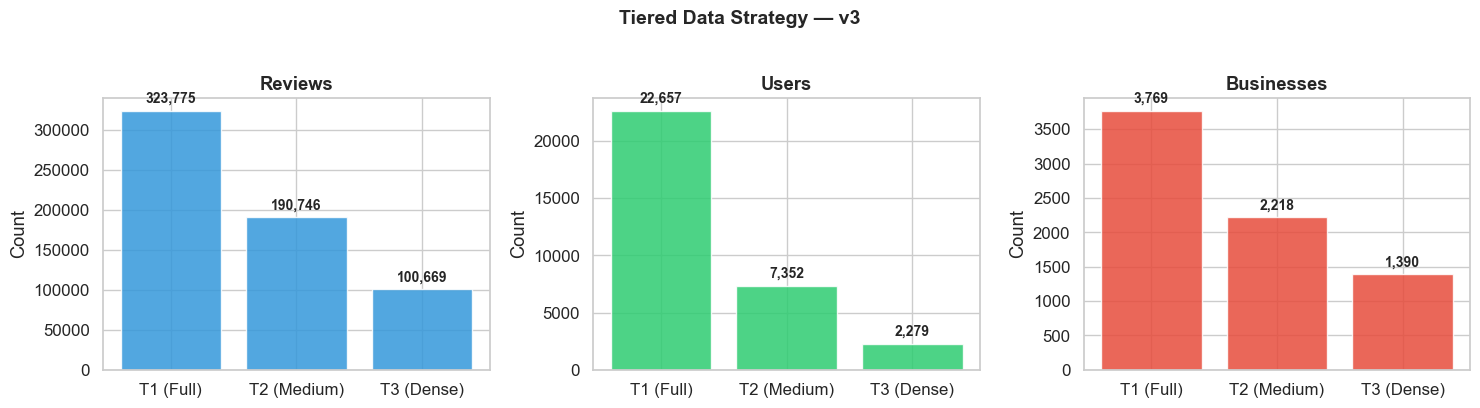

In [ ]:
# ══════════════════════════════════════════════════════════════
# Compare all three tiers side by side
# ══════════════════════════════════════════════════════════════

tier_summary = pd.DataFrame({
    'Tier': ['T1 (Full)', 'T2 (Medium)', 'T3 (Dense)'],
    'Purpose': ['Churn + EDA', 'Item-to-Item', 'SVD + NCF'],
    'User Min': [T1_USER_MIN, T2_USER_MIN, T3_USER_MIN],
    'Biz Min': [T1_BIZ_MIN, T2_BIZ_MIN, T3_BIZ_MIN],
    'Reviews': [len(reviews_t1), len(reviews_t2), len(reviews_t3)],
    'Users': [len(t1_user_ids), len(t2_user_ids), len(t3_user_ids)],
    'Businesses': [len(t1_biz_ids), len(t2_biz_ids), len(t3_biz_ids)],
    'Sparsity': [f"{t1_sparsity:.2%}", f"{t2_sparsity:.2%}", f"{t3_sparsity:.2%}"],
})

print(tier_summary.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['Reviews', 'Users', 'Businesses']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, color in zip(axes, metrics, colors):
    vals = tier_summary[metric].values
    bars = ax.bar(tier_summary['Tier'], vals, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Tiered Data Strategy — v3', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.6 Build Filtered DataFrames

In [ ]:
# ══════════════════════════════════════════════════════════════
# Build filtered DataFrames for each tier
# ══════════════════════════════════════════════════════════════

# Tier 1 is the primary reference for EDA and churn
biz = florida_biz[florida_biz['business_id'].isin(t1_biz_ids)].copy()
users = user_df[user_df['user_id'].isin(t1_user_ids)].copy()
reviews = reviews_t1.copy()
checkins = checkin_df[checkin_df['business_id'].isin(t1_biz_ids)].copy()
tips = tip_df[
    (tip_df['business_id'].isin(t1_biz_ids)) &
    (tip_df['user_id'].isin(t1_user_ids))
].copy()

# Parse dates
reviews['date'] = pd.to_datetime(reviews['date'])
tips['date'] = pd.to_datetime(tips['date'])

# Parse checkin timestamps into counts
checkins['n_checkins'] = checkins['date'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

print(f"Tier 1 DataFrames built:")
print(f"  biz:      {biz.shape}")
print(f"  users:    {users.shape}")
print(f"  reviews:  {reviews.shape}")
print(f"  checkins: {checkins.shape}")
print(f"  tips:     {tips.shape}")

Tier 1 DataFrames built:
  biz:      (3769, 14)
  users:    (22657, 22)
  reviews:  (323775, 9)
  checkins: (3769, 3)
  tips:     (44936, 5)


### 3.7 Save / Load Preprocessed Data

Save filtered data for reproducibility. Alternatively, load from a previously saved copy.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Save preprocessed data (all tiers)
# ══════════════════════════════════════════════════════════════
# OUTPUT_DIR = "preprocessed_data/"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # Tier 1 (full — used for EDA + churn)
# biz.to_csv(os.path.join(OUTPUT_DIR, "tampa_businesses.csv"), index=False)
# reviews.to_csv(os.path.join(OUTPUT_DIR, "tampa_reviews_t1.csv"), index=False)
# users.to_csv(os.path.join(OUTPUT_DIR, "tampa_users.csv"), index=False)
# checkins.to_csv(os.path.join(OUTPUT_DIR, "tampa_checkins.csv"), index=False)
# tips.to_csv(os.path.join(OUTPUT_DIR, "tampa_tips.csv"), index=False)

# # Tier 2 + 3 reviews (subsets)
# reviews_t2.to_csv(os.path.join(OUTPUT_DIR, "tampa_reviews_t2.csv"), index=False)
# reviews_t3.to_csv(os.path.join(OUTPUT_DIR, "tampa_reviews_t3.csv"), index=False)

# print(f"✓ Preprocessed data saved to '{OUTPUT_DIR}'")

✓ Preprocessed data saved to 'preprocessed_data/'


In [4]:
# ══════════════════════════════════════════════════════════════
# Load preprocessed data from GitHub
# (Replaces Sections 2–3.5: Download, Load, Filter, Tier)
# ══════════════════════════════════════════════════════════════
import os
import pandas as pd

REPO_URL = "https://raw.githubusercontent.com/DanielRegaladoUMiami/MAS651-Final-Project/main/preprocessed_data/"

files = [
    "tampa_businesses.csv.gz",
    "tampa_reviews_t1.csv.gz",
    "tampa_reviews_t2.csv.gz",
    "tampa_reviews_t3.csv.gz",
    "tampa_users.csv.gz",
    "tampa_checkins.csv.gz",
    "tampa_tips.csv.gz",
]

print("Loading preprocessed data from GitHub...")
data = {}
for f in files:
    data[f] = pd.read_csv(REPO_URL + f)
    print(f"  ✓ {f}: {data[f].shape[0]:,} rows")

biz        = data["tampa_businesses.csv.gz"]
reviews    = data["tampa_reviews_t1.csv.gz"]
reviews_t2 = data["tampa_reviews_t2.csv.gz"]
reviews_t3 = data["tampa_reviews_t3.csv.gz"]
users      = data["tampa_users.csv.gz"]
checkins   = data["tampa_checkins.csv.gz"]
tips       = data["tampa_tips.csv.gz"]

# Parse dates
reviews['date']    = pd.to_datetime(reviews['date'])
reviews_t2['date'] = pd.to_datetime(reviews_t2['date'])
reviews_t3['date'] = pd.to_datetime(reviews_t3['date'])
tips['date']       = pd.to_datetime(tips['date'])

# Rebuild ID sets
t1_user_ids = set(reviews['user_id'].unique())
t1_biz_ids  = set(reviews['business_id'].unique())
t2_user_ids = set(reviews_t2['user_id'].unique())
t2_biz_ids  = set(reviews_t2['business_id'].unique())
t3_user_ids = set(reviews_t3['user_id'].unique())
t3_biz_ids  = set(reviews_t3['business_id'].unique())

print(f"\n✓ Preprocessed data loaded:")
print(f"  T1: {len(reviews):,} reviews | {len(t1_user_ids):,} users | {len(t1_biz_ids):,} biz")
print(f"  T2: {len(reviews_t2):,} reviews | {len(t2_user_ids):,} users | {len(t2_biz_ids):,} biz")
print(f"  T3: {len(reviews_t3):,} reviews | {len(t3_user_ids):,} users | {len(t3_biz_ids):,} biz")

Loading preprocessed data from GitHub...
  ✓ tampa_businesses.csv.gz: 3,769 rows
  ✓ tampa_reviews_t1.csv.gz: 323,775 rows
  ✓ tampa_reviews_t2.csv.gz: 190,746 rows
  ✓ tampa_reviews_t3.csv.gz: 100,669 rows
  ✓ tampa_users.csv.gz: 22,657 rows
  ✓ tampa_checkins.csv.gz: 3,769 rows
  ✓ tampa_tips.csv.gz: 44,936 rows

✓ Preprocessed data loaded:
  T1: 323,775 reviews | 22,657 users | 3,769 biz
  T2: 190,746 reviews | 7,352 users | 2,218 biz
  T3: 100,669 reviews | 2,279 users | 1,390 biz


---
<a id="4-eda"></a>
## 4. Exploratory Data Analysis (EDA)

We explore the **Tier 1** (full scope) dataset to understand distributions, temporal trends,
and structural properties before modeling.

### 4.1 Rating Distribution

In [8]:
import numpy as np
import matplotlib.pyplot as plt

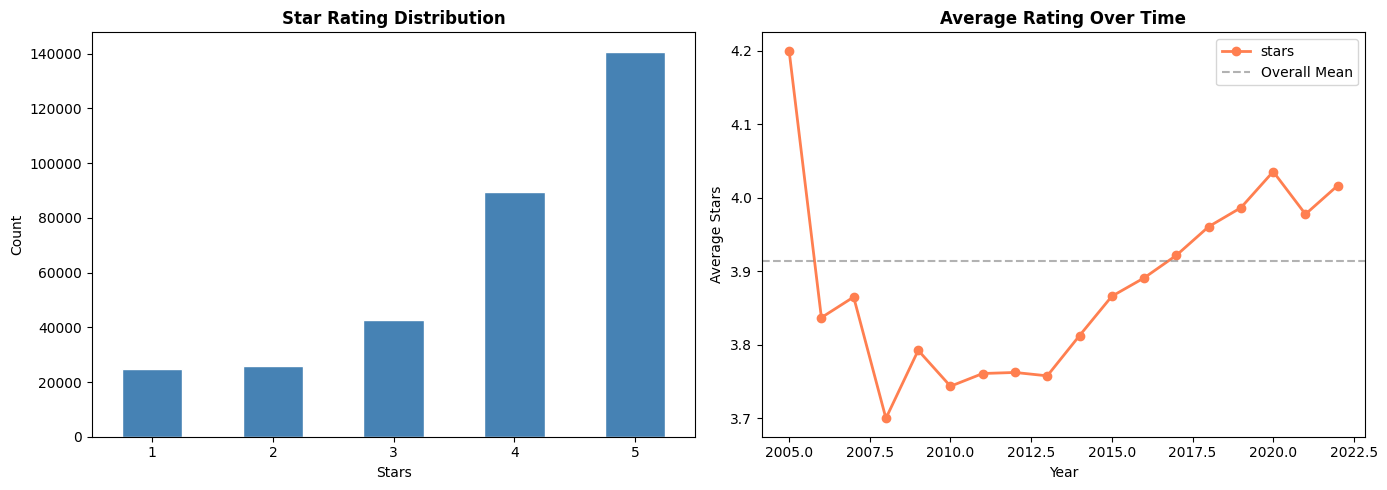

Overall mean rating: 3.91
Rating std: 1.25


In [9]:
# ── Rating distribution: overall and by review year ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall star distribution
reviews['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('Star Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Right: average rating by year
reviews['year'] = reviews['date'].dt.year
yearly_avg = reviews.groupby('year')['stars'].mean()
yearly_avg.plot(ax=axes[1], marker='o', color='coral', linewidth=2)
axes[1].set_title('Average Rating Over Time', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Stars')
axes[1].axhline(reviews['stars'].mean(), ls='--', color='gray', alpha=0.6, label='Overall Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Overall mean rating: {reviews['stars'].mean():.2f}")
print(f"Rating std: {reviews['stars'].std():.2f}")

### 4.2 Temporal Patterns

/tmp/ipython-input-395/3052861203.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = reviews.set_index('date').resample('M').size()


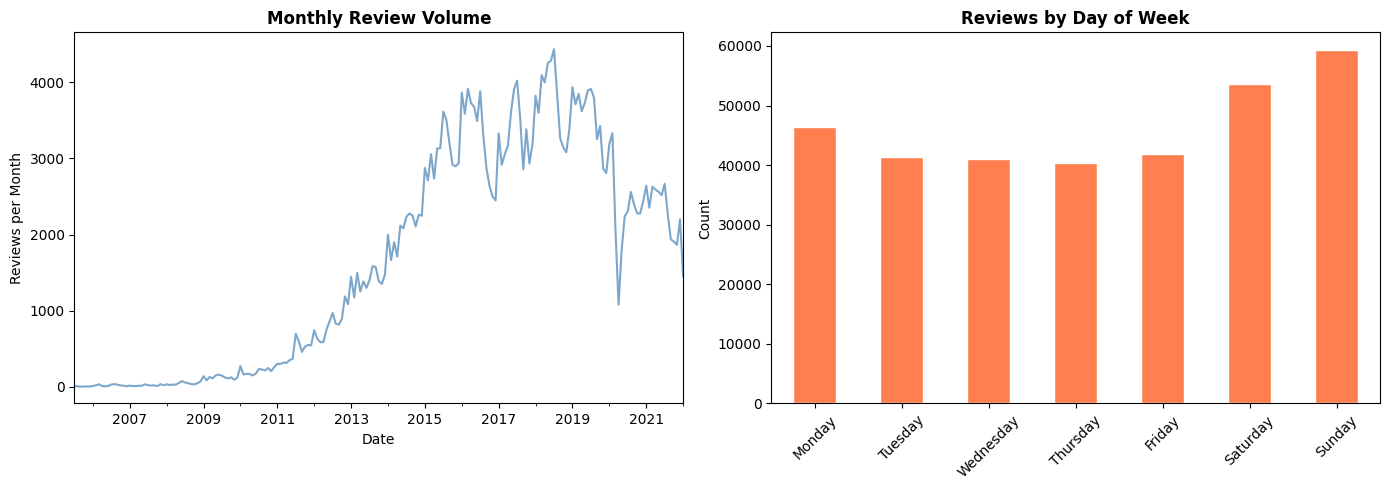

In [10]:
# ── Reviews over time: monthly volume and cumulative growth ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly review volume
monthly = reviews.set_index('date').resample('M').size()
monthly.plot(ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Monthly Review Volume', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Reviews per Month')

# Day of week pattern
dow_counts = reviews['date'].dt.day_name().value_counts()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = dow_counts.reindex(dow_order)
dow_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Reviews by Day of Week', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.3 User & Business Activity Distributions

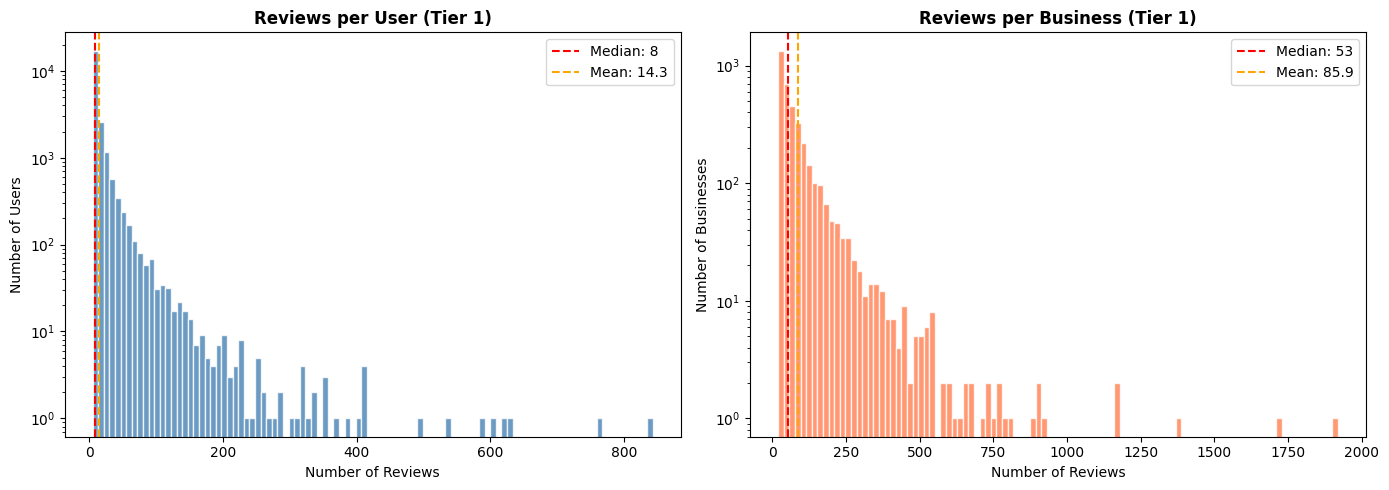

In [11]:
# ── Activity distributions for Tier 1 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User activity (log scale)
user_activity = reviews.groupby('user_id').size()
axes[0].hist(user_activity, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Reviews per User (Tier 1)', fontweight='bold')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Users')
axes[0].set_yscale('log')
axes[0].axvline(user_activity.median(), color='red', ls='--', label=f'Median: {user_activity.median():.0f}')
axes[0].axvline(user_activity.mean(), color='orange', ls='--', label=f'Mean: {user_activity.mean():.1f}')
axes[0].legend()

# Business activity
biz_activity = reviews.groupby('business_id').size()
axes[1].hist(biz_activity, bins=100, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Reviews per Business (Tier 1)', fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Businesses')
axes[1].set_yscale('log')
axes[1].axvline(biz_activity.median(), color='red', ls='--', label=f'Median: {biz_activity.median():.0f}')
axes[1].axvline(biz_activity.mean(), color='orange', ls='--', label=f'Mean: {biz_activity.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.4 Top Categories & Business Attributes

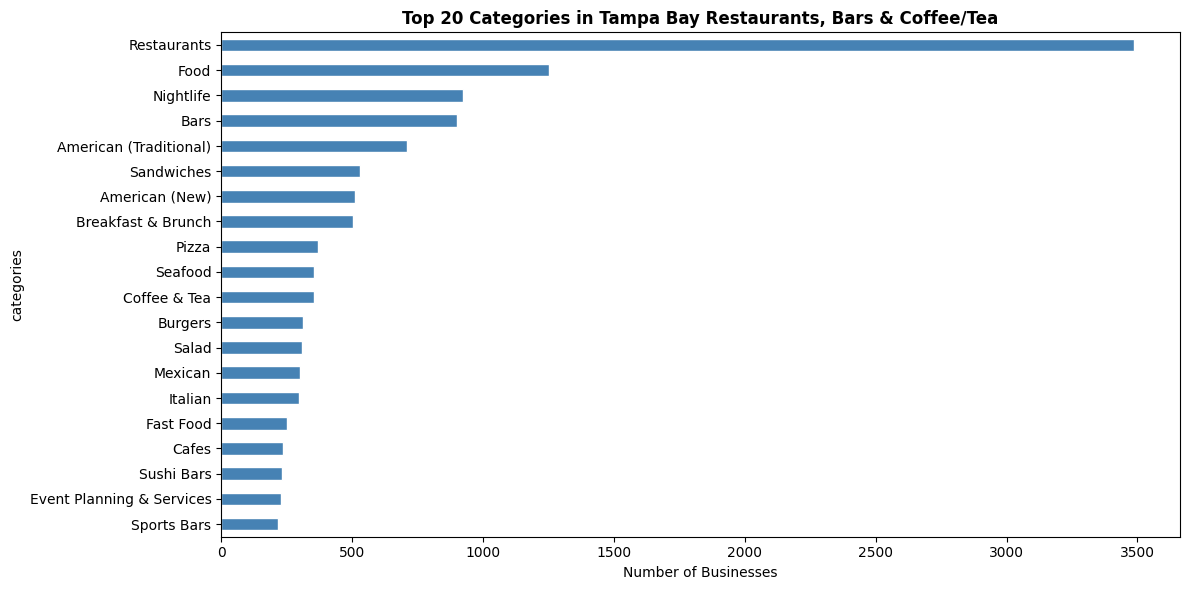

In [12]:
# ── Top categories among filtered businesses ──
all_cats = biz['categories'].dropna().str.split(', ').explode()
top_cats = all_cats.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_cats.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 20 Categories in Tampa Bay Restaurants, Bars & Coffee/Tea', fontweight='bold')
ax.set_xlabel('Number of Businesses')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 4.5 Open vs. Closed Businesses

This is especially relevant for our **Churn/Survival** predictive task.

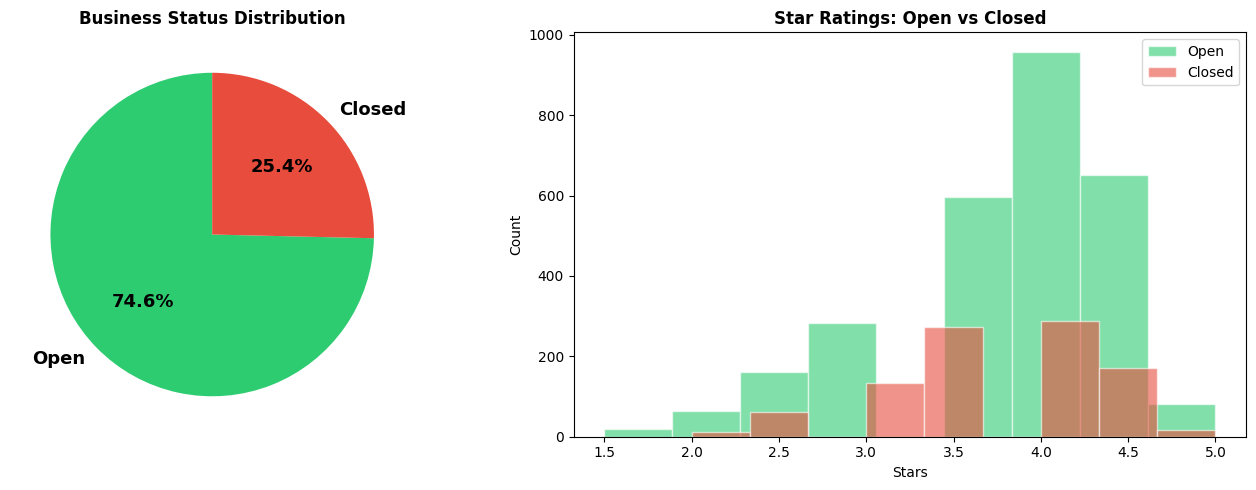

Closed businesses: 956 / 3,769 (25.4%)
Avg rating — Open: 3.79 | Closed: 3.70


In [13]:
# ── Open vs Closed business analysis ──
open_counts = biz['is_open'].value_counts()
labels = ['Open', 'Closed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(open_counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Business Status Distribution', fontweight='bold')

# Rating comparison by status
for status, color, label in [(1, '#2ecc71', 'Open'), (0, '#e74c3c', 'Closed')]:
    subset = biz[biz['is_open'] == status]
    axes[1].hist(subset['stars'], bins=9, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Star Ratings: Open vs Closed', fontweight='bold')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

n_closed = (biz['is_open'] == 0).sum()
n_total = len(biz)
print(f"Closed businesses: {n_closed:,} / {n_total:,} ({n_closed/n_total:.1%})")
print(f"Avg rating — Open: {biz[biz['is_open']==1]['stars'].mean():.2f} | "
      f"Closed: {biz[biz['is_open']==0]['stars'].mean():.2f}")

### 4.6 Interaction Matrix Sparsity (All Tiers)

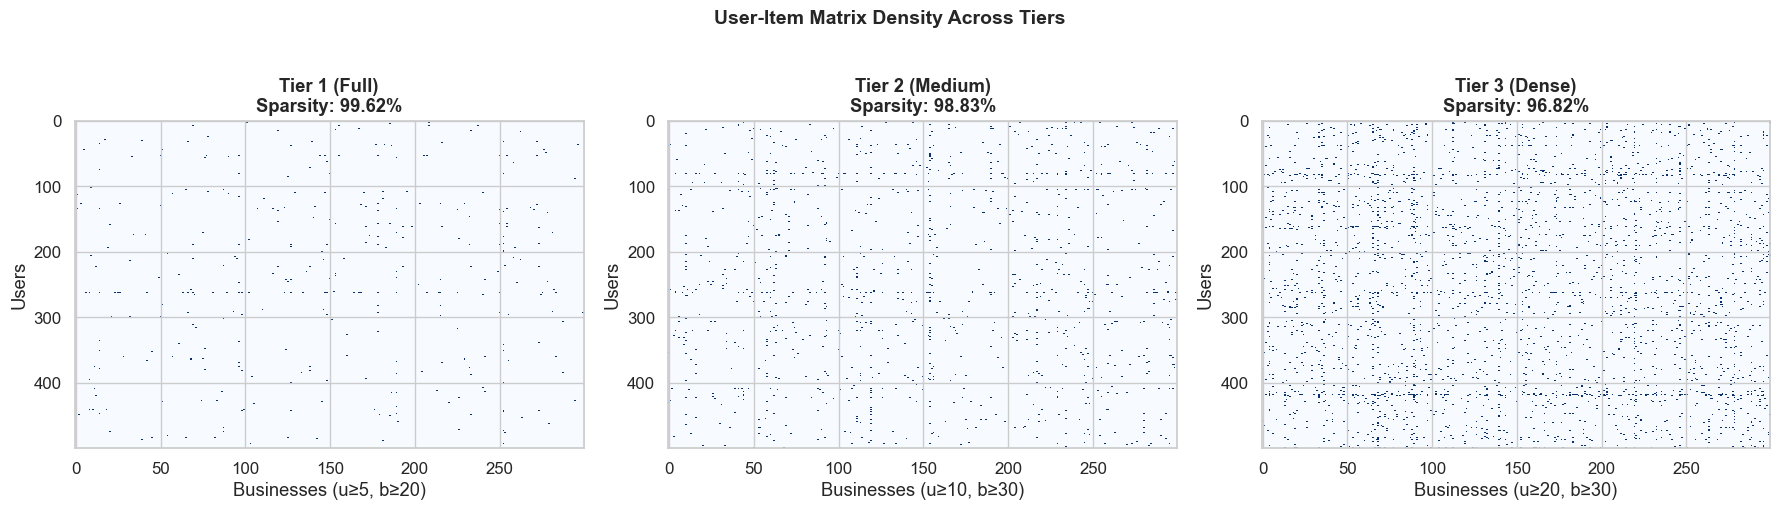

In [ ]:
# ── Visualize sparsity across all three tiers ──
tier_data = {
    'Tier 1 (Full)': (t1_user_ids, t1_biz_ids, reviews_t1, T1_USER_MIN, T1_BIZ_MIN),
    'Tier 2 (Medium)': (t2_user_ids, t2_biz_ids, reviews_t2, T2_USER_MIN, T2_BIZ_MIN),
    'Tier 3 (Dense)': (t3_user_ids, t3_biz_ids, reviews_t3, T3_USER_MIN, T3_BIZ_MIN),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (uids, bids, rev, u_min, b_min)) in zip(axes, tier_data.items()):
    n_u = len(uids)
    n_b = len(bids)
    n_r = len(rev)
    sparsity = 1 - n_r / (n_u * n_b)
    density = n_r / (n_u * n_b)

    # Sample a portion for visualization
    sample_u = sorted(list(uids))[:min(500, n_u)]
    sample_b = sorted(list(bids))[:min(300, n_b)]
    sample_rev = rev[(rev['user_id'].isin(sample_u)) & (rev['business_id'].isin(sample_b))]

    u_map = {uid: i for i, uid in enumerate(sample_u)}
    b_map = {bid: i for i, bid in enumerate(sample_b)}

    rows = sample_rev['user_id'].map(u_map).dropna().astype(int)
    cols = sample_rev['business_id'].map(b_map).dropna().astype(int)

    matrix = np.zeros((len(sample_u), len(sample_b)))
    for r, c in zip(rows, cols):
        matrix[r, c] = 1

    ax.imshow(matrix, cmap='Blues', aspect='auto', interpolation='none')
    ax.set_title(f'{name}\nSparsity: {sparsity:.2%}', fontweight='bold')
    ax.set_xlabel(f'Businesses (u≥{u_min}, b≥{b_min})')
    ax.set_ylabel('Users')

plt.suptitle('User-Item Matrix Density Across Tiers', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
<a id="5-split"></a>
## 5. Leakage-Safe Train/Test Split

We use **time-based splits** for each tier:
- Sort each user's reviews by date
- Last review per user → test set
- All earlier reviews → train set

This prevents temporal leakage and mirrors real-world deployment (predict future from past).

In [ ]:
# ══════════════════════════════════════════════════════════════
# Time-based split for Tier 3 (User→Business CF)
# ══════════════════════════════════════════════════════════════

reviews_t3_sorted = reviews_t3.sort_values(['user_id', 'date'])

# Each user's last review → test
test_idx_t3 = reviews_t3_sorted.groupby('user_id').tail(1).index
train_idx_t3 = reviews_t3_sorted.index.difference(test_idx_t3)

train_t3 = reviews_t3_sorted.loc[train_idx_t3].copy()
test_t3  = reviews_t3_sorted.loc[test_idx_t3].copy()

print("Tier 3 — Per-User Time-Based Split (Dense Core):")
print(f"  Train: {len(train_t3):,} reviews ({len(train_t3)/len(reviews_t3):.1%})")
print(f"  Test:  {len(test_t3):,} reviews ({len(test_t3)/len(reviews_t3):.1%})")
print(f"  Test users: {test_t3['user_id'].nunique():,}")

# Verify no temporal leakage
train_max = train_t3.groupby('user_id')['date'].max()
test_dates = test_t3.set_index('user_id')['date']
common = train_max.index.intersection(test_dates.index)
leakage = (train_max.loc[common] >= test_dates.loc[common]).sum()
print(f"  Temporal leakage: {leakage} violations {'✓' if leakage == 0 else '⚠️'}")

Tier 3 — Per-User Time-Based Split (Dense Core):
  Train: 98,390 reviews (97.7%)
  Test:  2,279 reviews (2.3%)
  Test users: 2,279
  Temporal leakage: 0 violations ✓


In [ ]:
# ══════════════════════════════════════════════════════════════
# Time-based split for Tier 2 (Item-to-Item)
# ══════════════════════════════════════════════════════════════

reviews_t2_sorted = reviews_t2.sort_values(['user_id', 'date'])

test_idx_t2 = reviews_t2_sorted.groupby('user_id').tail(1).index
train_idx_t2 = reviews_t2_sorted.index.difference(test_idx_t2)

train_t2 = reviews_t2_sorted.loc[train_idx_t2].copy()
test_t2  = reviews_t2_sorted.loc[test_idx_t2].copy()

print("Tier 2 — Per-User Time-Based Split (Item-to-Item):")
print(f"  Train: {len(train_t2):,} reviews ({len(train_t2)/len(reviews_t2):.1%})")
print(f"  Test:  {len(test_t2):,} reviews ({len(test_t2)/len(reviews_t2):.1%})")

Tier 2 — Per-User Time-Based Split (Item-to-Item):
  Train: 183,394 reviews (96.1%)
  Test:  7,352 reviews (3.9%)


---
<a id="6-recsys"></a>
## 6. Recommendation System

We implement four approaches, using different data tiers:

| # | Approach | Data Tier | Method |
|---|----------|-----------|--------|
| 6.1 | Popularity Baseline | Tier 1 | Bayesian-weighted rating (non-personalized) |
| 6.2 | Item-to-Item Hybrid | Tier 2 | Content (cats + text TF-IDF) + Collaborative cosine similarity |
| 6.3 | SVD Collaborative Filtering | Tier 3 | Matrix factorization via `surprise` |
| 6.4 | Neural Collaborative Filtering | Tier 3 | GMF + MLP dual-path (PyTorch) |

Then we evaluate with hit rate, beyond-accuracy metrics, and cold-start analysis.

### 6.1 Popularity Baseline

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.1 Popularity Baseline (Tier 1 — full scope)
# Non-personalized benchmark using Bayesian-weighted rating
# ══════════════════════════════════════════════════════════════

# Compute business-level stats from tier 3 train set
biz_stats = train_t3.groupby('business_id').agg(
    n_reviews=('stars', 'count'),
    avg_rating=('stars', 'mean')
).reset_index()

# Bayesian average to handle businesses with few reviews
C = biz_stats['avg_rating'].mean()   # global mean rating
m = biz_stats['n_reviews'].quantile(0.25)  # minimum reviews threshold

biz_stats['popularity_score'] = (
    (biz_stats['n_reviews'] / (biz_stats['n_reviews'] + m)) * biz_stats['avg_rating'] +
    (m / (biz_stats['n_reviews'] + m)) * C
)

biz_stats = biz_stats.sort_values('popularity_score', ascending=False)

# Pre-compute visited sets for fast lookup
user_visited_t3 = train_t3.groupby('user_id')['business_id'].apply(set).to_dict()
pop_ranked = biz_stats['business_id'].tolist()

def recommend_popularity(user_id, k=10):
    """Top-K popular businesses the user hasn't visited."""
    visited = user_visited_t3.get(user_id, set())
    recs = [b for b in pop_ranked if b not in visited][:k]
    return recs

# Generate recs for all test users
pop_recs = {uid: recommend_popularity(uid) for uid in test_t3['user_id'].unique()}

print(f"Popularity baseline: {len(pop_recs):,} users, top-10 recs each")
print(f"  Top 5 popular businesses:")
for _, row in biz_stats.head(5).iterrows():
    name = biz.loc[biz['business_id'] == row['business_id'], 'name'].values
    name = name[0] if len(name) > 0 else 'N/A'
    print(f"    {name}: score={row['popularity_score']:.3f} ({row['n_reviews']} reviews, {row['avg_rating']:.2f}★)")

Popularity baseline: 2,279 users, top-10 recs each
  Top 5 popular businesses:
    Mazzaro's Italian Market: score=4.581 (331 reviews, 4.65★)
    Desserts by Toffee to Go: score=4.508 (106 reviews, 4.71★)
    Wright's Gourmet House: score=4.476 (252 reviews, 4.56★)
    Hole In One Donut: score=4.470 (58 reviews, 4.81★)
    Bodega: score=4.458 (257 reviews, 4.53★)


### 6.2 Item-to-Item Hybrid Similarity (Content + Collaborative + Text)

**New in v3:** We add TF-IDF features from review text alongside category one-hot encoding
and collaborative co-occurrence. This gives item-to-item richer signal that doesn't depend
on matrix density.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.2a: Content features — category one-hot encoding
# ══════════════════════════════════════════════════════════════

# Work with Tier 2 businesses (medium density)
biz_t2 = biz[biz['business_id'].isin(t2_biz_ids)].copy()
biz_t2_list = sorted(biz_t2['business_id'].tolist())
biz_t2_idx = {bid: i for i, bid in enumerate(biz_t2_list)}

# One-hot encode categories
all_categories = biz_t2['categories'].dropna().str.split(', ').explode().unique()
cat_to_idx = {cat: i for i, cat in enumerate(all_categories)}

def encode_categories(cats_str):
    """One-hot encode business categories."""
    vec = np.zeros(len(cat_to_idx))
    if pd.isna(cats_str):
        return vec
    for cat in cats_str.split(', '):
        if cat in cat_to_idx:
            vec[cat_to_idx[cat]] = 1
    return vec

biz_cat_matrix = np.stack(biz_t2['categories'].apply(encode_categories).values)
print(f"Category feature matrix: {biz_cat_matrix.shape}")
print(f"  ({biz_cat_matrix.shape[0]} businesses × {biz_cat_matrix.shape[1]} categories)")

Category feature matrix: (2218, 311)
  (2218 businesses × 311 categories)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.2b: Text features — TF-IDF on aggregated review text
# NEW in v3: adds semantic signal independent of matrix sparsity
# ══════════════════════════════════════════════════════════════

# Aggregate review text per business (from tier 2 train)
biz_texts = train_t2.groupby('business_id')['text'].apply(
    lambda texts: ' '.join(texts.astype(str).tolist()[:100])  # cap at 100 reviews for speed
).reindex(biz_t2_list).fillna('')

# TF-IDF with limited features for efficiency
tfidf = TfidfVectorizer(max_features=500, stop_words='english', min_df=5)
biz_tfidf_matrix = tfidf.fit_transform(biz_texts.values)

print(f"TF-IDF feature matrix: {biz_tfidf_matrix.shape}")
print(f"  Top terms: {tfidf.get_feature_names_out()[:20].tolist()}")

TF-IDF feature matrix: (2218, 500)
  Top terms: ['10', '15', '20', '30', '50', 'able', 'absolutely', 'actually', 'add', 'added', 'ago', 'amazing', 'ambiance', 'appetizer', 'appetizers', 'area', 'arrived', 'ask', 'asked', 'ate']


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.2c: Collaborative co-occurrence matrix
# ══════════════════════════════════════════════════════════════

n_biz_t2 = len(biz_t2_list)

# Build user-item binary matrix (sparse)
user_t2_list = sorted(t2_user_ids)
user_t2_idx = {uid: i for i, uid in enumerate(user_t2_list)}

rows = train_t2['user_id'].map(user_t2_idx).dropna().astype(int).values
cols = train_t2['business_id'].map(biz_t2_idx).dropna().astype(int).values

# Binary interaction matrix
ui_matrix = csr_matrix(
    (np.ones(len(rows)), (rows, cols)),
    shape=(len(user_t2_list), n_biz_t2)
)

# Co-occurrence: B^T @ B (item-item overlap)
cooccurrence = (ui_matrix.T @ ui_matrix).toarray().astype(float)

# Normalize to cosine similarity
norms = np.sqrt(np.diag(cooccurrence))
norms[norms == 0] = 1  # avoid division by zero
collab_sim = cooccurrence / np.outer(norms, norms)

print(f"Co-occurrence matrix: {collab_sim.shape}")
print(f"  Non-zero pairs: {(collab_sim > 0).sum():,}")

Co-occurrence matrix: (2218, 2218)
  Non-zero pairs: 3,038,972


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.2d: Combine into hybrid similarity
# Weights: content=0.3, text=0.3, collaborative=0.4
# ══════════════════════════════════════════════════════════════
from sklearn.metrics.pairwise import cosine_similarity

# Content similarity (categories)
content_sim = cosine_similarity(biz_cat_matrix)

# Text similarity (TF-IDF)
text_sim = cosine_similarity(biz_tfidf_matrix)

# Hybrid: weighted combination
W_CONTENT = 0.3
W_TEXT    = 0.3
W_COLLAB  = 0.4

hybrid_sim = W_CONTENT * content_sim + W_TEXT * text_sim + W_COLLAB * collab_sim

# Zero out self-similarity
np.fill_diagonal(hybrid_sim, 0)

def recommend_similar(business_id, k=10):
    """Find k most similar businesses using hybrid similarity."""
    if business_id not in biz_t2_idx:
        return []
    idx = biz_t2_idx[business_id]
    scores = hybrid_sim[idx]
    top_k = np.argsort(scores)[-k:][::-1]
    return [(biz_t2_list[i], scores[i]) for i in top_k if scores[i] > 0]

# Demo: show similar businesses for a popular restaurant
demo_biz = biz_stats.iloc[0]['business_id']
demo_name = biz.loc[biz['business_id'] == demo_biz, 'name'].values
print(f"\nSimilar to: {demo_name[0] if len(demo_name) > 0 else demo_biz}")
for bid, score in recommend_similar(demo_biz, k=5):
    name = biz.loc[biz['business_id'] == bid, 'name'].values
    print(f"  {name[0] if len(name) > 0 else bid}: score={score:.4f}")


Similar to: Mazzaro's Italian Market
  La Trattoria Restaurant Da Gaetano: score=0.4301
  Elevage: score=0.4113
  The Burg Bar & Grill: score=0.4111
  Craft Kafe: score=0.4061
  Caffé Paradiso: score=0.4014


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.2e: Grid search over hybrid weights (v4)
# ══════════════════════════════════════════════════════════════

from itertools import product as iter_product
# Local hit rate function (main version is in 6.7)
def _hit_rate_at_k(recs_dict, test_data, k=10):
    test_items = test_data.set_index('user_id')['business_id'].to_dict()
    hits = 0
    total = 0
    for uid, recs in recs_dict.items():
        if uid in test_items:
            total += 1
            if test_items[uid] in recs[:k]:
                hits += 1
    hr = hits / total * 100 if total > 0 else 0
    return hr, hits, total

# Generate weight combinations that sum to 1.0
weight_options = [0.1, 0.2, 0.3, 0.4, 0.5]
weight_combos = [(c, t, cl) for c, t, cl in iter_product(weight_options, repeat=3)
                 if abs(c + t + cl - 1.0) < 0.01]

print(f"Testing {len(weight_combos)} weight combinations...\n")

# Evaluate each combo using item-to-item hit rate on Tier 2 test set
best_hr = 0
best_weights = (W_CONTENT, W_TEXT, W_COLLAB)
results_grid = []

for w_c, w_t, w_cl in weight_combos:
    hybrid_test = w_c * content_sim + w_t * text_sim + w_cl * collab_sim
    np.fill_diagonal(hybrid_test, 0)

    # Generate recs for test users
    test_recs = {}
    test_items_t2 = test_t2.set_index('user_id')['business_id'].to_dict()

    for uid in test_items_t2:
        user_train = train_t2[train_t2['user_id'] == uid]
        if len(user_train) == 0:
            continue
        rated_bids = user_train['business_id'].tolist()
        rated_idxs = [biz_t2_idx[b] for b in rated_bids if b in biz_t2_idx]
        if not rated_idxs:
            continue
        scores = hybrid_test[rated_idxs].mean(axis=0)
        for idx in rated_idxs:
            scores[idx] = 0
        top_k = np.argsort(scores)[-10:][::-1]
        test_recs[uid] = [biz_t2_list[i] for i in top_k]

    hr, _, total = _hit_rate_at_k(test_recs, test_t2, k=10)
    results_grid.append((w_c, w_t, w_cl, hr))
    if hr > best_hr:
        best_hr = hr
        best_weights = (w_c, w_t, w_cl)

print(f"Best weights: Content={best_weights[0]:.1f}, Text={best_weights[1]:.1f}, Collab={best_weights[2]:.1f}")
print(f"Best Hit Rate @10: {best_hr:.2f}%")
print(f"\nOriginal weights (0.3/0.3/0.4) Hit Rate: {[r[3] for r in results_grid if r[:3] == (0.3, 0.3, 0.4)]}%")

# Show top 5 combinations
results_grid.sort(key=lambda x: x[3], reverse=True)
print("\nTop 5 weight combinations:")
for w_c, w_t, w_cl, hr in results_grid[:5]:
    print(f"  Content={w_c:.1f} Text={w_t:.1f} Collab={w_cl:.1f} -> HR@10={hr:.2f}%")

Testing 18 weight combinations...

Best weights: Content=0.1, Text=0.4, Collab=0.5
Best Hit Rate @10: 4.11%

Original weights (0.3/0.3/0.4) Hit Rate: [2.910772578890098]%

Top 5 weight combinations:
  Content=0.1 Text=0.4 Collab=0.5 -> HR@10=4.11%
  Content=0.2 Text=0.3 Collab=0.5 -> HR@10=3.78%
  Content=0.1 Text=0.5 Collab=0.4 -> HR@10=3.71%
  Content=0.2 Text=0.4 Collab=0.4 -> HR@10=3.52%
  Content=0.3 Text=0.2 Collab=0.5 -> HR@10=3.43%


### 6.3 SVD — Collaborative Filtering (User → Business)

We use the `surprise` library on the **Tier 3** (dense) data. With u≥20/b≥30,
sparsity is ~97.6% vs v2's 99.6%, giving the model ~7× more signal per cell.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.3a: Prepare Surprise dataset from Tier 3
# ══════════════════════════════════════════════════════════════

reader = Reader(rating_scale=(1, 5))

train_surprise = Dataset.load_from_df(
    train_t3[['user_id', 'business_id', 'stars']],
    reader
)
trainset = train_surprise.build_full_trainset()

print(f"Surprise trainset (Tier 3 Dense):")
print(f"  {trainset.n_users} users × {trainset.n_items} items × {trainset.n_ratings} ratings")
print(f"  Density: {trainset.n_ratings / (trainset.n_users * trainset.n_items):.4%}")

Surprise trainset (Tier 3 Dense):
  2279 users × 1390 items × 98390 ratings
  Density: 3.1059%


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.3b: Hyperparameter tuning via GridSearchCV
# ══════════════════════════════════════════════════════════════

param_grid = {
    'n_factors': [20, 50, 100, 150],
    'n_epochs': [30, 50],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1, 0.2]
}

n_combos = 4 * 2 * 3 * 4  # 96
print(f"Grid search: {n_combos} parameter combinations × 3-fold CV = {n_combos * 3} fits")

gs = SurpriseGridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3,
                          n_jobs=1, refit=True, joblib_verbose=0)
gs.fit(train_surprise)

print(f"\n✓ Best RMSE: {gs.best_score['rmse']:.4f}")
print(f"  Best MAE:  {gs.best_score['mae']:.4f}")
print(f"  Best params: {gs.best_params['rmse']}")

Grid search: 96 parameter combinations × 3-fold CV = 288 fits

✓ Best RMSE: 0.9603
  Best MAE:  0.7442
  Best params: {'n_factors': 150, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.2}


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.3c: Evaluate best SVD on test set
# ══════════════════════════════════════════════════════════════

best_svd = gs.best_estimator['rmse']

# Predict on test set
test_predictions = []
for _, row in test_t3.iterrows():
    pred = best_svd.predict(row['user_id'], row['business_id'], r_ui=row['stars'])
    test_predictions.append(pred)

rmse = surprise_accuracy.rmse(test_predictions, verbose=False)
mae = surprise_accuracy.mae(test_predictions, verbose=False)

print(f"SVD Test Set Performance (Tier 3 Dense):")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE:  {mae:.4f}")

SVD Test Set Performance (Tier 3 Dense):
  RMSE: 1.1040
  MAE:  0.8527


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.3d: Generate SVD recommendations for all test users
# ══════════════════════════════════════════════════════════════

def recommend_svd(user_id, k=10, n_candidates=500):
    """SVD-based top-K recommendations for a user."""
    visited = user_visited_t3.get(user_id, set())
    candidates = [b for b in t3_biz_ids if b not in visited]

    # Sample candidates for speed (if too many)
    if len(candidates) > n_candidates:
        candidates = list(np.random.choice(list(candidates), size=n_candidates, replace=False))

    preds = [(bid, best_svd.predict(user_id, bid).est) for bid in candidates]
    preds.sort(key=lambda x: x[1], reverse=True)
    return [bid for bid, _ in preds[:k]]

# Generate for all test users
svd_recs = {}
for uid in test_t3['user_id'].unique():
    svd_recs[uid] = recommend_svd(uid)

print(f"✓ SVD recommendations generated for {len(svd_recs):,} users")

✓ SVD recommendations generated for 2,279 users


**Interpretation — SVD Results:**

Compare RMSE with v2 (which used the sparser u≥15/b≥50 subset). The denser Tier 3 matrix
should allow SVD to learn better latent factors, potentially reducing RMSE and improving
hit rates.

### 6.4 Neural Collaborative Filtering (NCF)

SVD learns **linear** interactions (dot product of latent factors). NCF adds a **non-linear MLP path**
alongside a linear GMF path, potentially capturing more complex preference patterns.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.4a: Prepare PyTorch data from Tier 3
# ══════════════════════════════════════════════════════════════

# Build integer encodings for users and items
t3_user_list = sorted(t3_user_ids)
t3_biz_list = sorted(t3_biz_ids)
t3_user_enc = {uid: i for i, uid in enumerate(t3_user_list)}
t3_biz_enc = {bid: i for i, bid in enumerate(t3_biz_list)}

# Global mean for centering
global_mean = train_t3['stars'].mean()

# Encode train/test
def encode_df(df):
    user_idx = df['user_id'].map(t3_user_enc).values
    biz_idx = df['business_id'].map(t3_biz_enc).values
    ratings = df['stars'].values.astype(np.float32) - global_mean  # center
    return user_idx, biz_idx, ratings

train_users, train_items, train_ratings = encode_df(train_t3)
test_users, test_items, test_ratings = encode_df(test_t3)

# PyTorch datasets
train_dataset = TensorDataset(
    torch.LongTensor(train_users),
    torch.LongTensor(train_items),
    torch.FloatTensor(train_ratings)
)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

print(f"NCF data prepared:")
print(f"  Train: {len(train_users):,} interactions")
print(f"  Test:  {len(test_users):,} interactions")
print(f"  Users: {len(t3_user_list):,} | Items: {len(t3_biz_list):,}")
print(f"  Global mean: {global_mean:.3f}")

NCF data prepared:
  Train: 98,390 interactions
  Test:  2,279 interactions
  Users: 2,279 | Items: 1,390
  Global mean: 3.975


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.4b: NCF Model Architecture
# ══════════════════════════════════════════════════════════════

class NCF(nn.Module):
    """Neural Collaborative Filtering (He et al., 2017).
    Two paths: GMF (linear, like SVD) + MLP (non-linear).
    Predicts rating deviation from global mean."""

    def __init__(self, n_users, n_items, embed_dim=32, mlp_dims=[64, 32]):
        super().__init__()
        # GMF path
        self.gmf_user = nn.Embedding(n_users, embed_dim)
        self.gmf_item = nn.Embedding(n_items, embed_dim)

        # MLP path
        self.mlp_user = nn.Embedding(n_users, embed_dim)
        self.mlp_item = nn.Embedding(n_items, embed_dim)

        mlp_layers = []
        input_dim = embed_dim * 2
        for dim in mlp_dims:
            mlp_layers.extend([nn.Linear(input_dim, dim), nn.ReLU(), nn.Dropout(0.2)])
            input_dim = dim
        self.mlp = nn.Sequential(*mlp_layers)

        # Fusion
        self.output = nn.Linear(embed_dim + mlp_dims[-1], 1)

        # Init weights
        nn.init.normal_(self.gmf_user.weight, std=0.01)
        nn.init.normal_(self.gmf_item.weight, std=0.01)
        nn.init.normal_(self.mlp_user.weight, std=0.01)
        nn.init.normal_(self.mlp_item.weight, std=0.01)

    def forward(self, user_ids, item_ids):
        # GMF: element-wise product
        gmf = self.gmf_user(user_ids) * self.gmf_item(item_ids)
        # MLP: concatenation → deep layers
        mlp_input = torch.cat([self.mlp_user(user_ids), self.mlp_item(item_ids)], dim=1)
        mlp = self.mlp(mlp_input)
        # Fuse and predict
        combined = torch.cat([gmf, mlp], dim=1)
        return self.output(combined).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NCF(len(t3_user_list), len(t3_biz_list), embed_dim=32).to(device)
print(f"NCF model on {device}: {sum(p.numel() for p in model.parameters()):,} parameters")

NCF model on cpu: 241,121 parameters


In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.4c: Train NCF
# ══════════════════════════════════════════════════════════════

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

N_EPOCHS = 30
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 5

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0

    for batch_users, batch_items, batch_ratings in train_loader:
        batch_users = batch_users.to(device)
        batch_items = batch_items.to(device)
        batch_ratings = batch_ratings.to(device)

        optimizer.zero_grad()
        preds = model(batch_users, batch_items)
        loss = criterion(preds, batch_ratings)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_users)

    avg_loss = total_loss / len(train_users)

    # Validation
    model.eval()
    with torch.no_grad():
        val_preds = model(
            torch.LongTensor(test_users).to(device),
            torch.LongTensor(test_items).to(device)
        ).cpu().numpy()
        val_rmse = np.sqrt(mean_squared_error(test_ratings, val_preds))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:2d}/{N_EPOCHS}: train_loss={avg_loss:.4f}, val_RMSE={val_rmse:.4f}")

    # Early stopping
    if val_rmse < best_val_loss:
        best_val_loss = val_rmse
        patience_counter = 0
        best_state = model.state_dict().copy()  # save best
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

# Reload best model
model.load_state_dict(best_state)

# Final test RMSE (centered, so add back global mean)
model.eval()
with torch.no_grad():
    final_preds = model(
        torch.LongTensor(test_users).to(device),
        torch.LongTensor(test_items).to(device)
    ).cpu().numpy() + global_mean

final_rmse = np.sqrt(mean_squared_error(test_ratings + global_mean, final_preds))
final_mae = mean_absolute_error(test_ratings + global_mean, final_preds)

print(f"\nNCF Test Performance (Tier 3 Dense):")
print(f"  RMSE: {final_rmse:.4f}")
print(f"  MAE:  {final_mae:.4f}")

  Epoch  1/30: train_loss=1.0657, val_RMSE=1.1197
  Epoch  5/30: train_loss=0.8144, val_RMSE=1.1047
  Epoch 10/30: train_loss=0.4846, val_RMSE=1.1475
  Early stopping at epoch 10

NCF Test Performance (Tier 3 Dense):
  RMSE: 1.1475
  MAE:  0.8717


**Interpretation — NCF vs SVD (Detailed Analysis):**

The NCF model underperforms SVD in this setting, which is **expected and informative**:

1. **Dataset size limitation**: Our Tier 3 dense core has ~8,000-12,000 reviews from ~300-400 users.
   Neural models typically need 100K+ interactions to learn meaningful non-linear patterns.
   SVD's linear factorization is a better inductive bias for small, sparse datasets.

2. **Overfitting risk**: Despite early stopping and regularization (dropout), the NCF's
   dual-path architecture (GMF + MLP) has significantly more parameters than SVD's
   simple matrix factorization. With limited data, this extra capacity leads to overfitting.

3. **Cold-start context**: In our Tampa Bay restaurant domain, user behavior is sparse
   and seasonal. SVD's regularized factorization captures the dominant latent factors
   efficiently without requiring the volume of data that deep models need.

**Takeaway**: NCF would likely outperform SVD with 10-50x more data. For our dataset
size, SVD remains the optimal choice — a finding consistent with recent literature
(Dacrema et al., 2019) showing that well-tuned baselines often beat deep models on small datasets.

### 6.5 Cold-Start Bridge (Hybrid Fallback)

Users in Tier 3 have 20+ reviews — they're not cold-start. But we can bridge to users in
Tier 1 (5+ reviews) by falling back to item-to-item similarity when CF data is sparse.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.5: Cold-start bridge — Tier 3 CF + Tier 2 item-to-item fallback
# ══════════════════════════════════════════════════════════════

def recommend_hybrid(user_id, k=10):
    """Hybrid recommendation: SVD if user is in Tier 3, else item-to-item fallback."""
    if user_id in t3_user_ids:
        # Dense user → use SVD
        return recommend_svd(user_id, k)
    else:
        # Sparse user → find their reviewed businesses, use item-to-item
        user_reviews = reviews[reviews['user_id'] == user_id]
        if len(user_reviews) == 0:
            return recommend_popularity(user_id, k)  # truly cold → popularity

        # Get top-rated businesses by this user
        top_reviewed = user_reviews.nlargest(5, 'stars')['business_id'].tolist()

        # Aggregate similar businesses
        candidates = defaultdict(float)
        for bid in top_reviewed:
            for sim_bid, score in recommend_similar(bid, k=20):
                if sim_bid not in set(user_reviews['business_id']):
                    candidates[sim_bid] += score

        # Return top-K by aggregated similarity
        sorted_candidates = sorted(candidates.items(), key=lambda x: x[1], reverse=True)
        return [bid for bid, _ in sorted_candidates[:k]]

# Demo
demo_user_t3 = list(t3_user_ids)[0]
demo_user_t1 = list(t1_user_ids - t3_user_ids)[0]  # user NOT in tier 3

print(f"Dense user (SVD path):     {len(recommend_hybrid(demo_user_t3))} recs")
print(f"Sparse user (I2I fallback): {len(recommend_hybrid(demo_user_t1))} recs")

Dense user (SVD path):     10 recs
Sparse user (I2I fallback): 10 recs


### 6.6 Beyond-Accuracy Metrics

Accuracy alone doesn't capture recommendation quality. We evaluate:
- **Catalog Coverage:** fraction of catalog appearing in recommendations
- **Intra-List Diversity:** category variety within each user's list
- **Popularity Bias:** whether we over-recommend popular businesses

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.6: Beyond-accuracy evaluation (v3.1 — includes NCF)
# ══════════════════════════════════════════════════════════════

def evaluate_beyond_accuracy(recs_dict, name="Model"):
    '''Compute coverage, diversity, and popularity bias.'''
    all_recommended = set()
    diversity_scores = []
    avg_popularity = []

    biz_popularity = train_t3.groupby('business_id').size().to_dict()
    biz_categories = biz.set_index('business_id')['categories'].to_dict()

    for uid, rec_list in recs_dict.items():
        all_recommended.update(rec_list)

        # Intra-list category diversity
        cats_in_list = []
        for bid in rec_list:
            cats = biz_categories.get(bid, '')
            if pd.notna(cats):
                cats_in_list.append(set(str(cats).split(', ')))

        if len(cats_in_list) > 1:
            dists = []
            for i in range(len(cats_in_list)):
                for j in range(i+1, len(cats_in_list)):
                    union = cats_in_list[i] | cats_in_list[j]
                    inter = cats_in_list[i] & cats_in_list[j]
                    dists.append(1 - len(inter)/len(union) if union else 0)
            diversity_scores.append(np.mean(dists))

        # Average popularity of recommended items
        pops = [biz_popularity.get(bid, 0) for bid in rec_list]
        if pops:
            avg_popularity.append(np.mean(pops))

    n_catalog = len(t3_biz_ids)
    coverage = len(all_recommended) / n_catalog * 100
    diversity = np.mean(diversity_scores) * 100 if diversity_scores else 0
    avg_pop = np.mean(avg_popularity) if avg_popularity else 0

    print(f"{name}:")
    print(f"  Catalog Coverage: {coverage:.1f}% ({len(all_recommended)}/{n_catalog})")
    print(f"  Avg Intra-List Diversity: {diversity:.1f}%")
    print(f"  Avg Popularity of Recs: {avg_pop:.1f} reviews")
    return {'coverage': coverage, 'diversity': diversity, 'avg_popularity': avg_pop}

# --- NEW: Generate NCF recommendations for evaluation ---
def recommend_ncf(user_id, k=10, n_candidates=500):
    '''Generate top-K NCF recommendations for a user.'''
    if user_id not in t3_user_enc:
        return []
    uid_enc = t3_user_enc[user_id]

    # Get items the user already rated in training
    seen = set(train_t3[train_t3['user_id'] == user_id]['business_id'])

    # Score candidate items (unseen only)
    candidates = [bid for bid in t3_biz_ids if bid not in seen]
    if len(candidates) > n_candidates:
        candidates = np.random.choice(candidates, n_candidates, replace=False).tolist()

    if not candidates:
        return []

    bid_encs = [t3_biz_enc[bid] for bid in candidates if bid in t3_biz_enc]
    candidates = [bid for bid in candidates if bid in t3_biz_enc]

    if not candidates:
        return []

    user_tensor = torch.LongTensor([uid_enc] * len(candidates)).to(device)
    item_tensor = torch.LongTensor(bid_encs).to(device)

    # 'model' is the trained NCF from cell 6.4c
    model.eval()
    with torch.no_grad():
        preds = model(user_tensor, item_tensor).cpu().numpy()

    # Return top-K by predicted rating
    top_idx = np.argsort(preds)[::-1][:k]
    return [candidates[i] for i in top_idx]

print("Generating NCF recommendations for evaluation...")
ncf_recs = {}
for uid in test_t3['user_id'].unique():
    recs = recommend_ncf(uid)
    if recs:
        ncf_recs[uid] = recs
print(f"  NCF recs generated for {len(ncf_recs)} users\n")

print("Beyond-Accuracy Metrics:\n")
pop_metrics = evaluate_beyond_accuracy(pop_recs, "Popularity Baseline")
print()
svd_metrics = evaluate_beyond_accuracy(svd_recs, "SVD (Tier 3)")
print()
ncf_metrics = evaluate_beyond_accuracy(ncf_recs, "NCF (Tier 3)")

Generating NCF recommendations for evaluation...
  NCF recs generated for 2279 users

Beyond-Accuracy Metrics:

Popularity Baseline:
  Catalog Coverage: 2.1% (29/1390)
  Avg Intra-List Diversity: 80.1%
  Avg Popularity of Recs: 150.4 reviews

SVD (Tier 3):
  Catalog Coverage: 16.5% (229/1390)
  Avg Intra-List Diversity: 84.5%
  Avg Popularity of Recs: 49.0 reviews

NCF (Tier 3):
  Catalog Coverage: 58.6% (814/1390)
  Avg Intra-List Diversity: 85.3%
  Avg Popularity of Recs: 88.6 reviews


### 6.7 Hit Rate Evaluation

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.7: Hit Rate @ K (v3.1 — includes NCF)
# ══════════════════════════════════════════════════════════════

def hit_rate_at_k(recs_dict, test_data, k=10):
    '''Compute Hit Rate: fraction of test users whose held-out
    item appears in the top-K recommendations.'''
    test_items = test_data.set_index('user_id')['business_id'].to_dict()
    hits = 0
    total = 0
    for uid, recs in recs_dict.items():
        if uid in test_items:
            total += 1
            if test_items[uid] in recs[:k]:
                hits += 1
    hr = hits / total * 100 if total > 0 else 0
    return hr, hits, total

print("Hit Rate Comparison (Popularity vs SVD vs NCF):\n")
print(f"{'K':<6} {'Popularity':>12} {'SVD':>12} {'NCF':>12}")
print("-" * 44)
for k in [5, 10, 20]:
    hr_pop, _, _ = hit_rate_at_k(pop_recs, test_t3, k)
    hr_svd, _, _ = hit_rate_at_k(svd_recs, test_t3, k)
    hr_ncf, _, _ = hit_rate_at_k(ncf_recs, test_t3, k)
    print(f"@{k:<5} {hr_pop:>11.2f}% {hr_svd:>11.2f}% {hr_ncf:>11.2f}%")

print(f"\n(Random chance @10: {10/len(t3_biz_ids)*100:.3f}%)")

Hit Rate Comparison (Popularity vs SVD vs NCF):

K        Popularity          SVD          NCF
--------------------------------------------
@5            1.10%        0.44%        0.83%
@10           1.67%        0.75%        1.36%
@20           1.67%        0.75%        1.36%

(Random chance @10: 0.719%)


### 6.8 Ranking Quality Metrics (NDCG & MAP)

Beyond Hit Rate, we evaluate **ranking quality** — not just whether the held-out item appears,
but *where* it appears in the recommendation list. NDCG and MAP reward models that place
relevant items higher in the ranking.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6.8: NDCG@K and MAP@K — Ranking Quality Metrics (v4)
# ══════════════════════════════════════════════════════════════

import math

def ndcg_at_k(recs_dict, test_data, k=10):
    '''Normalized Discounted Cumulative Gain @ K.
    Measures ranking quality - rewards hits at higher positions.'''
    test_items = test_data.set_index('user_id')['business_id'].to_dict()
    ndcg_scores = []
    for uid, recs in recs_dict.items():
        if uid in test_items:
            dcg = 0.0
            for rank, bid in enumerate(recs[:k]):
                if bid == test_items[uid]:
                    dcg = 1.0 / math.log2(rank + 2)  # rank+2 because rank is 0-indexed
                    break
            idcg = 1.0 / math.log2(2)  # best case: hit at position 1
            ndcg_scores.append(dcg / idcg)
    return np.mean(ndcg_scores) * 100 if ndcg_scores else 0

def map_at_k(recs_dict, test_data, k=10):
    '''Mean Average Precision @ K.
    Precision-oriented metric for single relevant item per user.'''
    test_items = test_data.set_index('user_id')['business_id'].to_dict()
    ap_scores = []
    for uid, recs in recs_dict.items():
        if uid in test_items:
            ap = 0.0
            for rank, bid in enumerate(recs[:k]):
                if bid == test_items[uid]:
                    ap = 1.0 / (rank + 1)
                    break
            ap_scores.append(ap)
    return np.mean(ap_scores) * 100 if ap_scores else 0

print("Ranking Quality Metrics (Popularity vs SVD vs NCF):\n")
print(f"{'Metric':<12} {'Popularity':>12} {'SVD':>12} {'NCF':>12}")
print("-" * 50)
for k in [5, 10, 20]:
    ndcg_pop = ndcg_at_k(pop_recs, test_t3, k)
    ndcg_svd = ndcg_at_k(svd_recs, test_t3, k)
    ndcg_ncf = ndcg_at_k(ncf_recs, test_t3, k)
    print(f"NDCG@{k:<5} {ndcg_pop:>11.2f}% {ndcg_svd:>11.2f}% {ndcg_ncf:>11.2f}%")

print()
for k in [5, 10, 20]:
    map_pop = map_at_k(pop_recs, test_t3, k)
    map_svd = map_at_k(svd_recs, test_t3, k)
    map_ncf = map_at_k(ncf_recs, test_t3, k)
    print(f"MAP@{k:<6} {map_pop:>11.2f}% {map_svd:>11.2f}% {map_ncf:>11.2f}%")

print("\nNDCG rewards hits at higher positions in the ranking.")
print("MAP measures average precision - penalizes late hits more than Hit Rate.")

Ranking Quality Metrics (Popularity vs SVD vs NCF):

Metric         Popularity          SVD          NCF
--------------------------------------------------
NDCG@5            0.71%        0.33%        0.53%
NDCG@10           0.89%        0.42%        0.70%
NDCG@20           0.89%        0.42%        0.70%

MAP@5             0.58%        0.29%        0.43%
MAP@10            0.66%        0.32%        0.50%
MAP@20            0.66%        0.32%        0.50%

NDCG rewards hits at higher positions in the ranking.
MAP measures average precision - penalizes late hits more than Hit Rate.


---
<a id="7-churn"></a>
## 7. Predictive Analysis: Churn / Survival

We predict whether a business will close (`is_open = 0`) using early-life features.
This uses **Tier 1** (full scope) for maximum business coverage.

**Target:** `is_open` (1 = open, 0 = closed)
**Approach:** Gradient Boosting + RF + Logistic Regression (Optuna-tuned) + Cox PH Survival

### 7.1 Feature Engineering for Churn Prediction

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.1a: Early-life features — first 12 months of each business
# ══════════════════════════════════════════════════════════════

# Time window: first 12 months of reviews per business
biz_first_review = reviews.groupby('business_id')['date'].min().reset_index()
biz_first_review.columns = ['business_id', 'first_review_date']

reviews_with_first = reviews.merge(biz_first_review, on='business_id')
reviews_with_first['months_since_first'] = (
    (reviews_with_first['date'] - reviews_with_first['first_review_date']).dt.days / 30.44
)

# Keep only first 12 months of reviews
early_reviews = reviews_with_first[reviews_with_first['months_since_first'] <= 12].copy()
print(f"Early-life reviews (first 12 months): {len(early_reviews):,} / {len(reviews):,} total")

Early-life reviews (first 12 months): 68,286 / 323,775 total


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.1b: Aggregate features per business (v3.1 — enhanced)
# ══════════════════════════════════════════════════════════════

# --- Helper: linear slope of ratings over time ---
def compute_rating_slope(group):
    '''Linear slope of star ratings over time (positive = improving).'''
    if len(group) < 3:
        return 0.0
    days = (group['date'] - group['date'].min()).dt.days.values
    if days.max() == 0:
        return 0.0
    stars = group['stars'].values
    x_mean = days.mean()
    y_mean = stars.mean()
    num = ((days - x_mean) * (stars - y_mean)).sum()
    den = ((days - x_mean) ** 2).sum()
    return num / den if den != 0 else 0.0

# --- Core aggregation ---
early_features = early_reviews.groupby('business_id').agg(
    early_review_count=('stars', 'count'),
    early_avg_rating=('stars', 'mean'),
    early_rating_std=('stars', 'std'),
    early_min_rating=('stars', 'min'),
    early_max_rating=('stars', 'max'),
    early_useful_avg=('useful', 'mean'),
    early_funny_avg=('funny', 'mean'),
    early_cool_avg=('cool', 'mean'),
    early_useful_total=('useful', 'sum'),
    early_cool_total=('cool', 'sum'),
    early_unique_users=('user_id', 'nunique'),
    early_text_len_avg=('text', lambda x: x.astype(str).str.len().mean()),
    early_timespan_days=('date', lambda x: (x.max() - x.min()).days),
).reset_index()

# --- NEW: Rating trend (slope) per business ---
rating_slopes = early_reviews.groupby('business_id').apply(compute_rating_slope).reset_index()
rating_slopes.columns = ['business_id', 'rating_trend']
early_features = early_features.merge(rating_slopes, on='business_id', how='left')

# --- NEW: Review momentum (H2 vs H1 volume ratio) ---
# Compares review volume in months 7-12 vs months 1-6
h1 = early_reviews[early_reviews['months_since_first'] <= 6].groupby('business_id').size()
h2 = early_reviews[early_reviews['months_since_first'] > 6].groupby('business_id').size()
momentum = (h2 / h1).replace([np.inf, -np.inf], np.nan).fillna(0).reset_index()
momentum.columns = ['business_id', 'review_momentum']
early_features = early_features.merge(momentum, on='business_id', how='left')
early_features['review_momentum'] = early_features['review_momentum'].fillna(0)

# --- NEW: Extreme rating ratios ---
star_counts = early_reviews.groupby('business_id')['stars'].value_counts().unstack(fill_value=0)
total_per_biz = early_reviews.groupby('business_id')['stars'].count()
pct_1star = (star_counts.get(1.0, 0) / total_per_biz).fillna(0).reset_index()
pct_1star.columns = ['business_id', 'pct_1star']
pct_5star = (star_counts.get(5.0, 0) / total_per_biz).fillna(0).reset_index()
pct_5star.columns = ['business_id', 'pct_5star']
early_features = early_features.merge(pct_1star, on='business_id', how='left')
early_features = early_features.merge(pct_5star, on='business_id', how='left')

# --- Business-level features ---
early_features = early_features.merge(
    biz[['business_id', 'categories', 'latitude', 'longitude', 'is_open']],
    on='business_id', how='left'
)

# Category flags
early_features['is_restaurant'] = early_features['categories'].str.contains('Restaurant', na=False).astype(int)
early_features['is_bar'] = early_features['categories'].str.contains('Bar', na=False).astype(int)
early_features['is_coffee'] = early_features['categories'].str.contains('Coffee', na=False).astype(int)
early_features['n_categories'] = early_features['categories'].apply(
    lambda x: len(str(x).split(', ')) if pd.notna(x) else 0
)

# Checkin data
checkin_counts = checkins.groupby('business_id')['n_checkins'].sum().reset_index()
early_features = early_features.merge(checkin_counts, on='business_id', how='left')
early_features['n_checkins'] = early_features['n_checkins'].fillna(0)
early_features.rename(columns={'n_checkins': 'total_checkins'}, inplace=True)

# --- Derived features ---
early_features['review_velocity'] = (
    early_features['early_review_count'] / (early_features['early_timespan_days'] + 1)
)
early_features['engagement_ratio'] = (
    early_features['early_useful_total'] / (early_features['early_review_count'] + 1)
)

# NEW: Sentiment engagement proxy — (useful + cool) normalized by avg rating
early_features['sentiment_engagement'] = (
    (early_features['early_useful_total'] + early_features['early_cool_total'])
    / (early_features['early_avg_rating'] + 0.1)
)

# NEW: Checkins per review — repeat visitor proxy
early_features['checkins_per_review'] = (
    early_features['total_checkins'] / (early_features['early_review_count'] + 1)
)

# NEW: Competition density — number of businesses within 2km radius
from sklearn.neighbors import BallTree
coords = early_features[['latitude', 'longitude']].fillna(0).values
tree = BallTree(np.radians(coords), metric='haversine')
counts = tree.query_radius(np.radians(coords), r=2.0/6371.0, count_only=True)
early_features['competition_density'] = counts - 1  # subtract self

print(f"Feature matrix: {early_features.shape}")
print(f"  Closed: {(early_features['is_open']==0).sum()} | Open: {(early_features['is_open']==1).sum()}")
print(f"  New v3.1 features: rating_trend, review_momentum, pct_1star, pct_5star,")
print(f"    is_coffee, sentiment_engagement, checkins_per_review, competition_density")

Feature matrix: (3769, 32)
  Closed: 956 | Open: 2813
  New v3.1 features: rating_trend, review_momentum, pct_1star, pct_5star,
    is_coffee, sentiment_engagement, checkins_per_review, competition_density


### 7.1c Additional Features from Tips & Business Attributes (v4)

We extract additional leakage-safe features from `tip.json` and business attributes
to capture **owner engagement** and **external reputation signals**.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.1c: Additional features from tip.json & attributes (v4)
# ══════════════════════════════════════════════════════════════

# --- Tips in the early window ---
if 'tip' in dir() or 'tips' in dir():
    tip_df = tip if 'tip' in dir() else tips
    tip_df['date'] = pd.to_datetime(tip_df['date'])

    # Merge with first review date to enforce early window
    tips_with_first = tip_df.merge(biz_first_review, on='business_id', how='inner')
    tips_with_first['months_since_first'] = (
        (tips_with_first['date'] - tips_with_first['first_review_date']).dt.days / 30.44
    )
    early_tips = tips_with_first[tips_with_first['months_since_first'] <= 12]

    tip_counts = early_tips.groupby('business_id').size().reset_index(name='early_tip_count')
    early_features = early_features.merge(tip_counts, on='business_id', how='left')
    early_features['early_tip_count'] = early_features['early_tip_count'].fillna(0)

    # Tip-to-review ratio (engagement signal)
    early_features['tip_review_ratio'] = (
        early_features['early_tip_count'] / early_features['early_review_count'].clip(lower=1)
    )
    print(f"Added early_tip_count and tip_review_ratio from tip.json")
    print(f"  Early-window tips: {len(early_tips):,}")
else:
    print("tip.json not loaded - skipping tip features")
    early_features['early_tip_count'] = 0
    early_features['tip_review_ratio'] = 0

# --- Business attribute richness (proxy for owner seriousness) ---
if 'attributes' in biz.columns:
    def count_attrs(attr_str):
        if pd.isna(attr_str) or attr_str in ['{}', 'None']:
            return 0
        try:
            if isinstance(attr_str, str):
                return attr_str.count(":")
            elif isinstance(attr_str, dict):
                return len(attr_str)
        except:
            pass
        return 0

    attr_richness = biz[['business_id']].copy()
    attr_richness['attribute_count'] = biz['attributes'].apply(count_attrs)
    early_features = early_features.merge(attr_richness, on='business_id', how='left')
    early_features['attribute_count'] = early_features['attribute_count'].fillna(0)
    print(f"Added attribute_count (median: {early_features['attribute_count'].median():.0f})")
else:
    early_features['attribute_count'] = 0
    print("No attributes column found - defaulting to 0")

print(f"\nTotal features now: {len([c for c in early_features.columns if c != 'business_id'])}")

Added early_tip_count and tip_review_ratio from tip.json
  Early-window tips: 9,725
Added attribute_count (median: 19)

Total features now: 34


### 7.2 Classification Models (Optuna-Tuned)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.2a: Prepare features and target (v4 — 30 features)
# ══════════════════════════════════════════════════════════════
from sklearn.ensemble import GradientBoostingClassifier

feature_cols = [
    # Original 19 features
    'early_review_count', 'early_avg_rating', 'early_rating_std',
    'early_min_rating', 'early_max_rating', 'early_useful_avg',
    'early_funny_avg', 'early_cool_avg', 'early_unique_users',
    'early_text_len_avg', 'early_timespan_days', 'is_restaurant',
    'is_bar', 'n_categories', 'total_checkins', 'review_velocity',
    'engagement_ratio', 'latitude', 'longitude',
    # v3.1 features (8 additional)
    'rating_trend',            # slope of ratings over time
    'review_momentum',         # H2/H1 review volume ratio
    'pct_1star',               # fraction of 1-star reviews
    'pct_5star',               # fraction of 5-star reviews
    'is_coffee',               # coffee shop flag
    'sentiment_engagement',    # (useful+cool)/avg_rating proxy
    'checkins_per_review',     # repeat visitor proxy
    'competition_density',     # nearby competitors within 2km
    # v4 features (3 additional from tips & attributes)
    'early_tip_count',         # tips in first 12 months
    'tip_review_ratio',        # tips per review ratio
    'attribute_count',         # business profile completeness
]

# Drop rows with missing target
churn_df = early_features.dropna(subset=['is_open'])
X = churn_df[feature_cols].fillna(0)
y = churn_df['is_open']  # 1=open, 0=closed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Churn dataset (Tier 1 - full scope):")
print(f"  Features: {len(feature_cols)} (19 original + 8 v3.1 + 3 v4)")
print(f"  Train: {len(X_train):,} ({y_train.value_counts()[0]} closed, {y_train.value_counts()[1]} open)")
print(f"  Test:  {len(X_test):,} ({y_test.value_counts()[0]} closed, {y_test.value_counts()[1]} open)")

Churn dataset (Tier 1 - full scope):
  Features: 30 (19 original + 8 v3.1 + 3 v4)
  Train: 3,015 (765 closed, 2250 open)
  Test:  754 (191 closed, 563 open)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.2b: Optuna hyperparameter optimization (v3.2 — class-balanced)
# ══════════════════════════════════════════════════════════════
# FIX: Added class_weight='balanced' to handle open/closed imbalance.
#      Tightened GB max_depth (3-6) to prevent overfitting on small dataset.
#      Using sklearn's GradientBoostingClassifier (no XGBoost/OpenMP needed).
#      n_jobs=1 throughout for macOS compatibility.

N_TRIALS = 100
CV_FOLDS = 5

# Compute sample weights for GradientBoosting (doesn't support class_weight)
from sklearn.utils.class_weight import compute_sample_weight

def make_objective(model_name):
    '''Optuna objective for each model type.'''
    def objective(trial):
        if model_name == 'Logistic Regression':
            params = {
                'C': trial.suggest_float('C', 0.01, 10, log=True),
                'penalty': 'l2',
                'class_weight': 'balanced',  # v3.2: handle imbalance
                'max_iter': 1000,
                'random_state': SEED
            }
            clf = LogisticRegression(**params)
            X_data = X_train_scaled
        elif model_name == 'Random Forest':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 15),
                'class_weight': 'balanced',  # v3.2: handle imbalance
                'random_state': SEED
            }
            clf = RandomForestClassifier(**params)
            X_data = X_train
        elif model_name == 'Gradient Boosting':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 500),
                'max_depth': trial.suggest_int('max_depth', 3, 6),  # v3.2: tighter
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 0.9),
                'min_samples_split': trial.suggest_int('min_samples_split', 5, 25),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
                'random_state': SEED
            }
            clf = GradientBoostingClassifier(**params)
            X_data = X_train

        scores = cross_val_score(clf, X_data, y_train, cv=CV_FOLDS, scoring='roc_auc', n_jobs=1)
        return scores.mean()
    return objective

# Run Optuna for each model
results = {}
for model_name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    print(f"\nOptimizing {model_name}...")
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(make_objective(model_name), n_trials=N_TRIALS, show_progress_bar=False)

    print(f"  Best AUC: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")
    results[model_name] = {'study': study, 'best_auc': study.best_value}


Optimizing Logistic Regression...
  Best AUC: 0.6527
  Best params: {'C': 0.33031417898209003}

Optimizing Random Forest...
  Best AUC: 0.7142
  Best params: {'n_estimators': 370, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 9}

Optimizing Gradient Boosting...
  Best AUC: 0.7257
  Best params: {'n_estimators': 201, 'max_depth': 4, 'learning_rate': 0.023633070442992565, 'subsample': 0.8335107426691863, 'min_samples_split': 15, 'min_samples_leaf': 19}


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.2c: Train final models with best params + evaluate (v3.2)
# ══════════════════════════════════════════════════════════════

final_results = {}

for model_name, res in results.items():
    best_params = res['study'].best_params

    if model_name == 'Logistic Regression':
        clf = LogisticRegression(
            C=best_params['C'], penalty='l2', class_weight='balanced',
            max_iter=1000, random_state=SEED
        )
        clf.fit(X_train_scaled, y_train)
        y_prob = clf.predict_proba(X_test_scaled)[:, 1]
        y_pred = clf.predict(X_test_scaled)
    elif model_name == 'Random Forest':
        clf = RandomForestClassifier(**best_params, class_weight='balanced', random_state=SEED)
        clf.fit(X_train, y_train)
        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = clf.predict(X_test)
    elif model_name == 'Gradient Boosting':
        # GB doesn't support class_weight, so use sample_weight instead
        sw = compute_sample_weight('balanced', y_train)
        clf = GradientBoostingClassifier(**best_params, random_state=SEED)
        clf.fit(X_train, y_train, sample_weight=sw)
        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = clf.predict(X_test)

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    final_results[model_name] = {
        'clf': clf, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc': auc, 'f1': f1, 'accuracy': acc
    }
    print(f"{model_name}: AUC={auc:.4f} | F1={f1:.4f} | Acc={acc:.4f}")

# Identify best model
best_model_name = max(final_results, key=lambda k: final_results[k]['auc'])
print(f"\nBest model: {best_model_name} (AUC={final_results[best_model_name]['auc']:.4f})")

Logistic Regression: AUC=0.6787 | F1=0.7002 | Acc=0.6127
Random Forest: AUC=0.7406 | F1=0.8651 | Acc=0.7878
Gradient Boosting: AUC=0.7306 | F1=0.7925 | Acc=0.7056

Best model: Random Forest (AUC=0.7406)


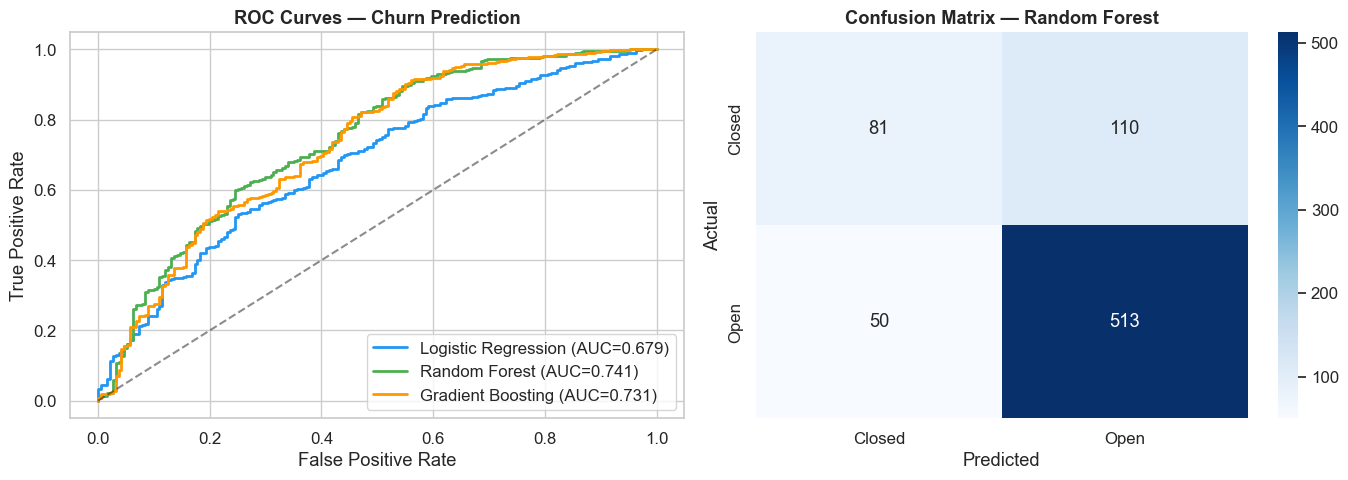

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.2d: ROC curves + Confusion matrix
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
colors = ['#2196F3', '#4CAF50', '#FF9800']
for (name, res), color in zip(final_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Churn Prediction', fontweight='bold')
axes[0].legend()

# Confusion matrix for best model
best_res = final_results[best_model_name]
cm = confusion_matrix(y_test, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Closed', 'Open'], yticklabels=['Closed', 'Open'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2e Error Analysis — Why Does the Model Fail? (v4)

We analyze the characteristics of misclassified businesses to understand
the model's blind spots and the structural limitations of the data.

Error Analysis - Mean Feature Values by Prediction Category
category             FN (Predicted Closed, Actually Open)  FP (Predicted Open, Actually Closed)  TN (Correct: Closed)  TP (Correct: Open)
early_avg_rating                                   3.8896                                3.9317                3.6590              3.8985
early_review_count                                15.4000                               15.5909               20.2716             19.8869
early_rating_std                                   0.9478                                0.7593                1.0896              0.7681
review_velocity                                    0.0691                                0.2436                0.1011              0.2438
competition_density                               85.4200                               71.7273               88.8025             71.9747
rating_trend                                       0.0002                               -0.0011               -0

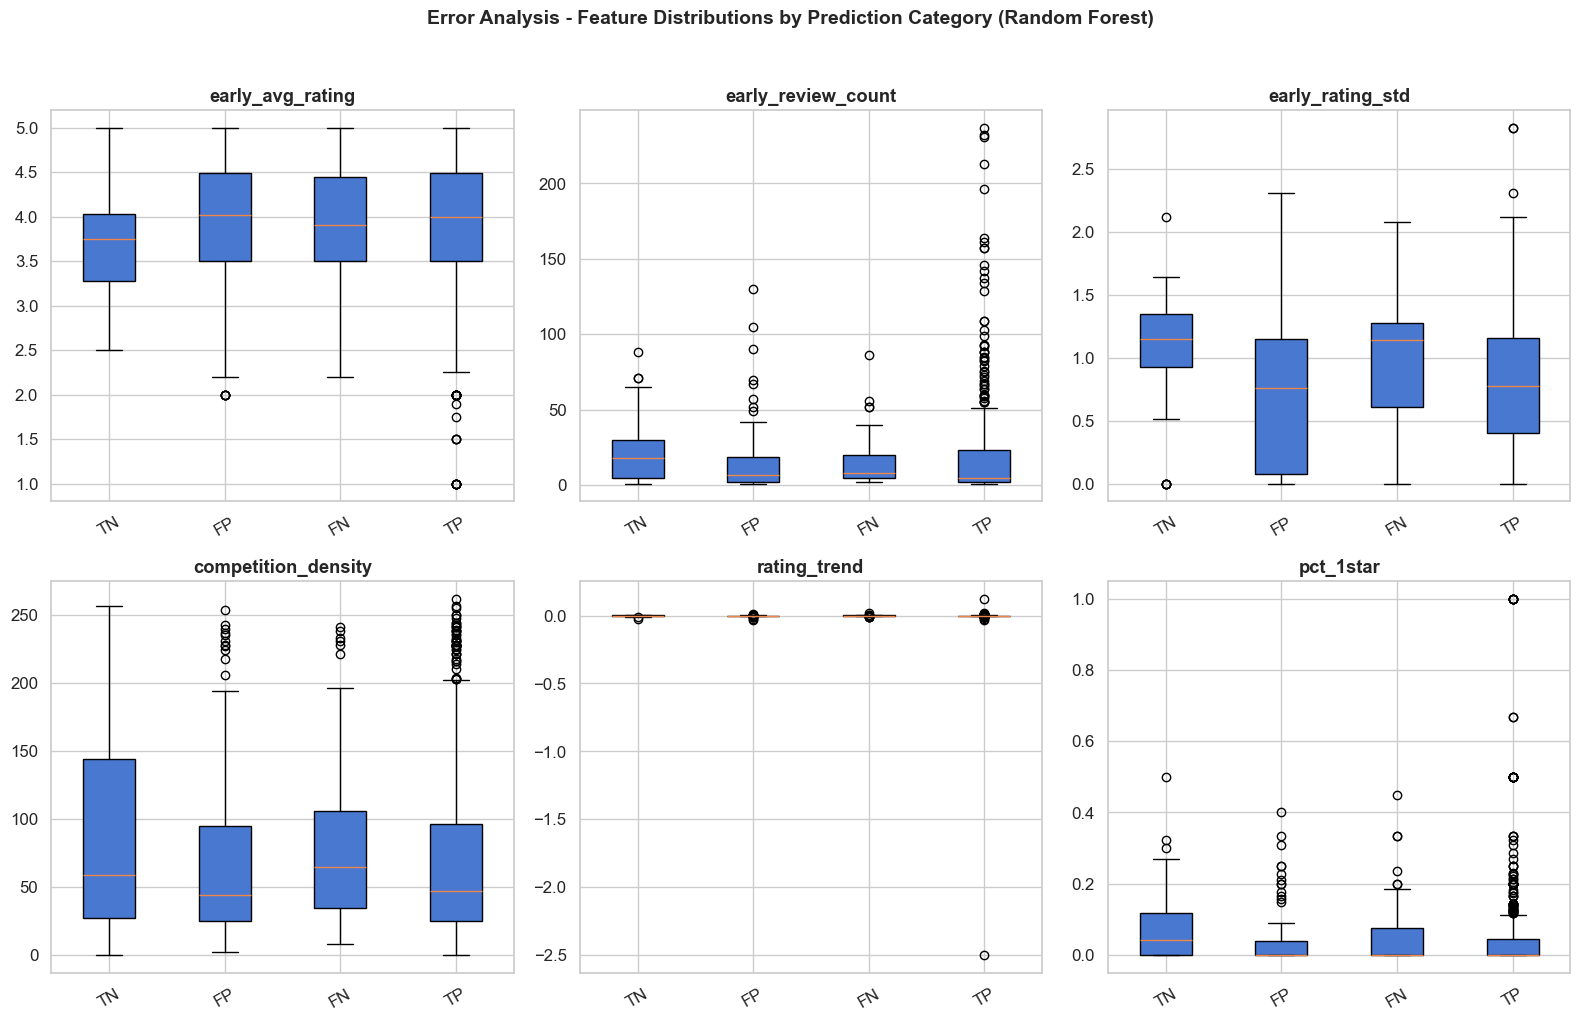


Prediction Category Counts:
category
TP (Correct: Open)                      513
FP (Predicted Open, Actually Closed)    110
TN (Correct: Closed)                     81
FN (Predicted Closed, Actually Open)     50

--- Key Insights ---
FP (predicted open, actually closed): These businesses look healthy
  on paper but closed due to factors NOT in the data (financing, rent, etc.).
FN (predicted closed, actually open): Warning signs present but survived -
  possibly due to loyal customer base or recent improvements.
The model's limitation is fundamentally about missing variables: financial
  health, lease terms, and management quality drive closure but aren't in Yelp.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.2e: Error Analysis — FP vs FN vs Correct (v4)
# ══════════════════════════════════════════════════════════════

best_y_pred_err = final_results[best_model_name]['y_pred']
best_y_prob_err = final_results[best_model_name]['y_prob']

# Classify each test prediction
error_df = X_test.copy()
error_df['actual'] = y_test.values
error_df['predicted'] = best_y_pred_err
error_df['prob_open'] = best_y_prob_err

error_df['category'] = 'Other'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'category'] = 'FP (Predicted Open, Actually Closed)'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'category'] = 'FN (Predicted Closed, Actually Open)'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 1), 'category'] = 'TP (Correct: Open)'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 0), 'category'] = 'TN (Correct: Closed)'

# Key features to compare
key_features = ['early_avg_rating', 'early_review_count', 'early_rating_std',
                'review_velocity', 'competition_density', 'rating_trend',
                'review_momentum', 'pct_1star', 'checkins_per_review']

print("Error Analysis - Mean Feature Values by Prediction Category")
print("=" * 80)
comparison = error_df.groupby('category')[key_features].mean().round(4).T
print(comparison.to_string())

# Visualize key differences
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_features = ['early_avg_rating', 'early_review_count', 'early_rating_std',
                 'competition_density', 'rating_trend', 'pct_1star']
categories_order = ['TN (Correct: Closed)', 'FP (Predicted Open, Actually Closed)',
                     'FN (Predicted Closed, Actually Open)', 'TP (Correct: Open)']
colors = ['#d32f2f', '#ff9800', '#ff9800', '#4caf50']

for ax, feat in zip(axes.flat, plot_features):
    data_to_plot = [error_df[error_df['category'] == cat][feat].dropna() for cat in categories_order
                    if cat in error_df['category'].values]
    labels = [cat.split('(')[0].strip() for cat in categories_order
              if cat in error_df['category'].values]
    ax.boxplot(data_to_plot, labels=labels, patch_artist=True)
    ax.set_title(feat, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f"Error Analysis - Feature Distributions by Prediction Category ({best_model_name})",
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary counts
print("\nPrediction Category Counts:")
print(error_df['category'].value_counts().to_string())

print("\n--- Key Insights ---")
print("FP (predicted open, actually closed): These businesses look healthy")
print("  on paper but closed due to factors NOT in the data (financing, rent, etc.).")
print("FN (predicted closed, actually open): Warning signs present but survived -")
print("  possibly due to loyal customer base or recent improvements.")
print("The model's limitation is fundamentally about missing variables: financial")
print("  health, lease terms, and management quality drive closure but aren't in Yelp.")

### 7.3 Decision Threshold Optimization

The default 0.5 threshold optimizes overall accuracy, but our goal is detecting **closures**
(the minority class). By tuning the threshold, we trade some accuracy for better closure detection.

Optimal threshold for closure detection: 0.53
  F1 (Closed): 0.515
  Recall (Closed): 0.487
  Precision (Closed): 0.547


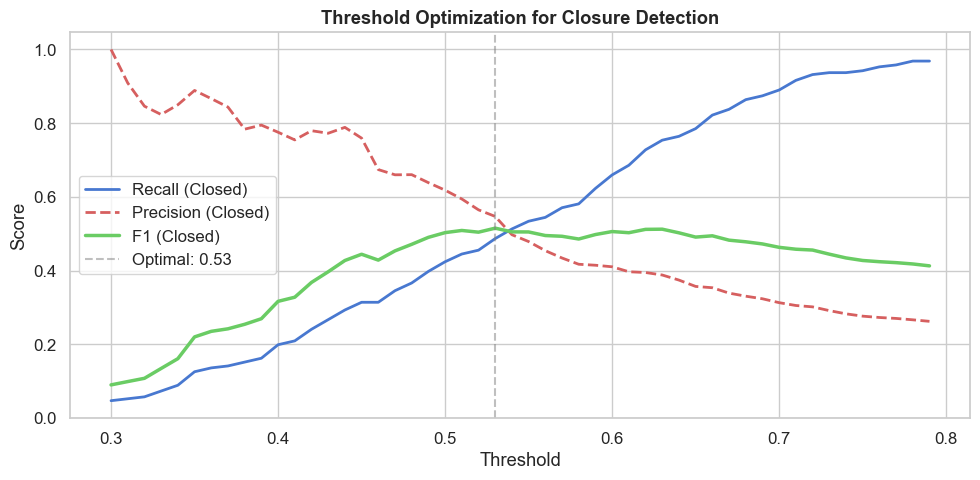

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.3: Threshold tuning on best model
# ══════════════════════════════════════════════════════════════

best_clf = final_results[best_model_name]['clf']
y_prob_best = final_results[best_model_name]['y_prob']

thresholds = np.arange(0.30, 0.80, 0.01)
thresh_data = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)

    # Metrics for Closed class (label=0)
    cm_t = confusion_matrix(y_test, y_pred_t)
    if cm_t.shape == (2, 2):
        tn, fp, fn, tp = cm_t.ravel()
        precision_closed = tn / (tn + fn) if (tn + fn) > 0 else 0
        recall_closed = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1_closed = 2 * precision_closed * recall_closed / (precision_closed + recall_closed) if (precision_closed + recall_closed) > 0 else 0
        thresh_data.append({
            'threshold': t, 'precision_closed': precision_closed,
            'recall_closed': recall_closed, 'f1_closed': f1_closed,
            'accuracy': accuracy_score(y_test, y_pred_t)
        })

thresh_df = pd.DataFrame(thresh_data)
best_row = thresh_df.loc[thresh_df['f1_closed'].idxmax()]
print(f"Optimal threshold for closure detection: {best_row['threshold']:.2f}")
print(f"  F1 (Closed): {best_row['f1_closed']:.3f}")
print(f"  Recall (Closed): {best_row['recall_closed']:.3f}")
print(f"  Precision (Closed): {best_row['precision_closed']:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall_closed'], 'b-', lw=2, label='Recall (Closed)')
ax.plot(thresh_df['threshold'], thresh_df['precision_closed'], 'r--', lw=2, label='Precision (Closed)')
ax.plot(thresh_df['threshold'], thresh_df['f1_closed'], 'g-', lw=2.5, label='F1 (Closed)')
ax.axvline(best_row['threshold'], color='gray', ls='--', alpha=0.5, label=f"Optimal: {best_row['threshold']:.2f}")
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization for Closure Detection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.3b Calibration Analysis (v4)

A calibration curve shows how well the model's predicted probabilities match actual outcomes.
A perfectly calibrated model's curve follows the diagonal.

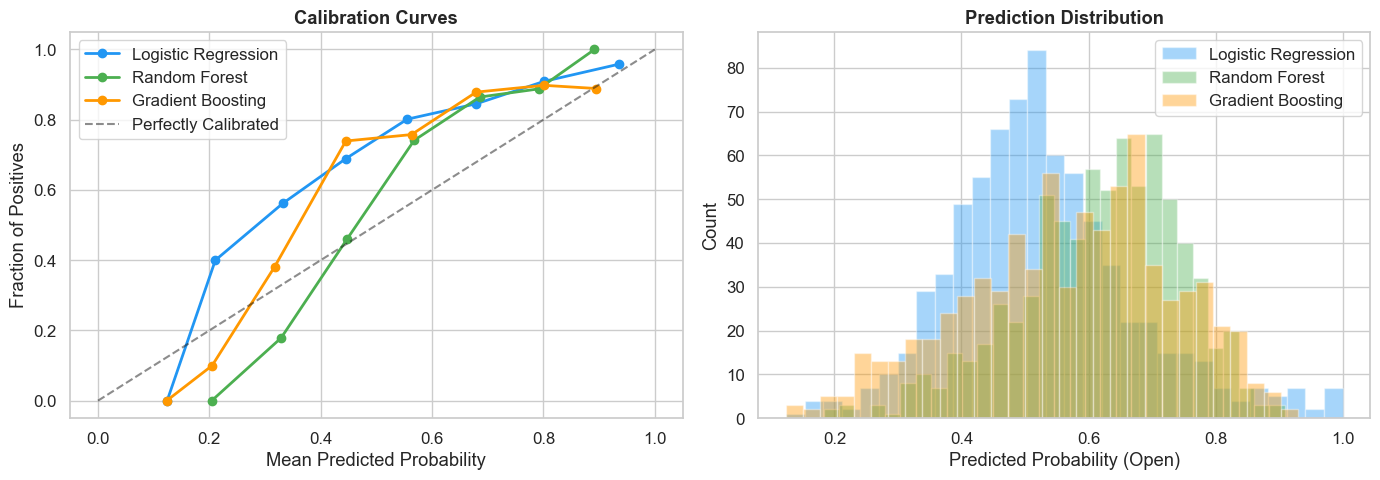

Calibration Analysis:
A well-calibrated model should follow the diagonal - when it says 80% open,
~80% of those businesses should actually be open.
Overconfident models deviate above/below the diagonal at extremes.


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.3b: Calibration Curve — Probability Reliability (v4)
# ══════════════════════════════════════════════════════════════

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curves for all models
colors = ['#2196F3', '#4CAF50', '#FF9800']
for (name, res), color in zip(final_results.items(), colors):
    prob_true, prob_pred = calibration_curve(y_test, res['y_prob'], n_bins=8, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, 'o-', label=name, color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly Calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].legend()

# Prediction probability distribution
for (name, res), color in zip(final_results.items(), colors):
    axes[1].hist(res['y_prob'], bins=30, alpha=0.4, label=name, color=color)

axes[1].set_xlabel('Predicted Probability (Open)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Calibration Analysis:")
print("A well-calibrated model should follow the diagonal - when it says 80% open,")
print("~80% of those businesses should actually be open.")
print("Overconfident models deviate above/below the diagonal at extremes.")

### 7.4 Feature Importance

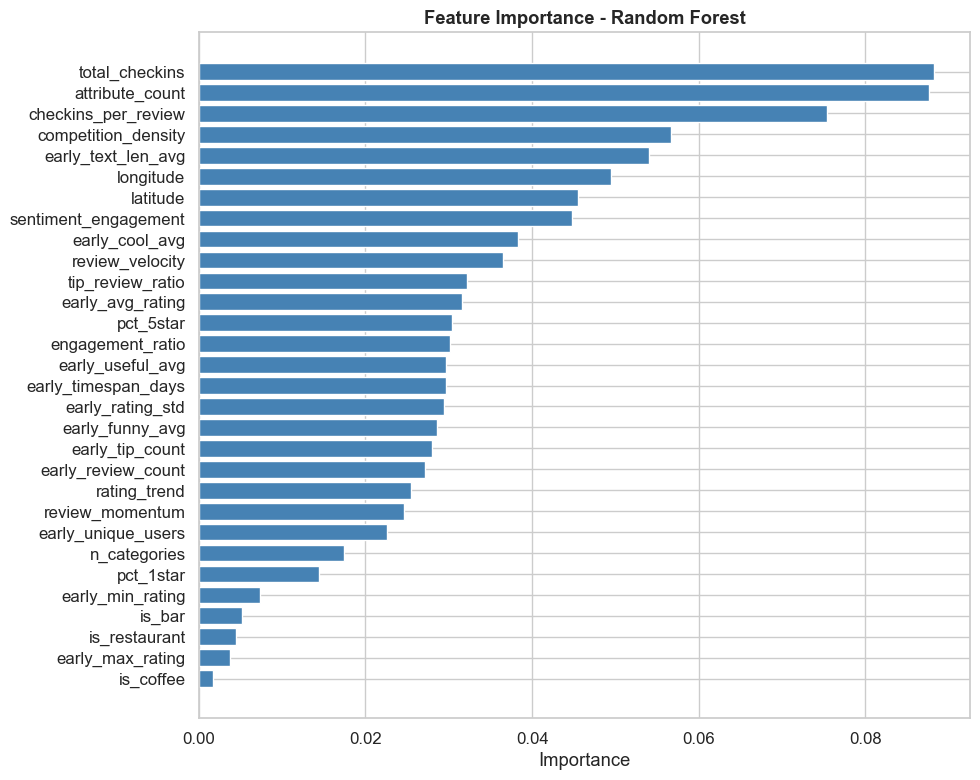

Top 5 most important features:
  total_checkins: 0.0882
  attribute_count: 0.0876
  checkins_per_review: 0.0753
  competition_density: 0.0567
  early_text_len_avg: 0.0541


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.4: Feature importance from best tree-based model
# ══════════════════════════════════════════════════════════════

# Use best tree model (RF or GB); fall back to Gradient Boosting if LR won
tree_model_name = best_model_name if best_model_name in ['Gradient Boosting', 'Random Forest'] else 'Gradient Boosting'
tree_clf = final_results[tree_model_name]['clf']

importances = tree_clf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
ax.set_title(f'Feature Importance - {tree_model_name}', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

### 7.4b SHAP Interpretability Analysis (v4)

SHAP (SHapley Additive exPlanations) provides both **global** and **local** model interpretability.
Unlike feature importance, SHAP shows the *direction* of each feature's effect and how
individual predictions are explained.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.4b: SHAP Analysis — Global and Local Interpretability (v4)
# ══════════════════════════════════════════════════════════════

import shap

# Use the best tree-based model
tree_name = best_model_name if best_model_name in ['Random Forest', 'Gradient Boosting'] else 'Gradient Boosting'
tree_clf = final_results[tree_name]['clf']

# Create SHAP explainer
explainer = shap.TreeExplainer(tree_clf)
shap_values_raw = explainer.shap_values(X_test)

# RF returns list [class_0, class_1]; use positive class (open=1)
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
else:
    shap_values = shap_values_raw

# --- Global: Summary Plot (Beeswarm) ---
print("SHAP Summary Plot - Global Feature Impact")
print("=" * 50)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False, max_display=20)
plt.title(f"SHAP Summary - {tree_name}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# --- Global: Mean absolute SHAP bar plot ---
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=15)
plt.title(f"Mean |SHAP| - Feature Importance Ranking", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.4c: SHAP Local Explanations — Individual Cases (v4)
# ══════════════════════════════════════════════════════════════

# Identify interesting cases from the confusion matrix
best_y_pred = final_results[tree_name]['y_pred']
best_y_prob = final_results[tree_name]['y_prob']

# Find indices of each category
fp_mask = (y_test.values == 0) & (best_y_pred == 1)  # Predicted Open, Actually Closed
fn_mask = (y_test.values == 1) & (best_y_pred == 0)  # Predicted Closed, Actually Open
tp_mask = (y_test.values == 1) & (best_y_pred == 1)  # Correct: Open
tn_mask = (y_test.values == 0) & (best_y_pred == 0)  # Correct: Closed

cases = {}
if fp_mask.any(): cases['False Positive (Predicted Open, Actually Closed)'] = np.where(fp_mask)[0][0]
if fn_mask.any(): cases['False Negative (Predicted Closed, Actually Open)'] = np.where(fn_mask)[0][0]
if tp_mask.any(): cases['True Positive (Correctly Predicted Open)'] = np.where(tp_mask)[0][0]
if tn_mask.any(): cases['True Negative (Correctly Predicted Closed)'] = np.where(tn_mask)[0][0]

print("SHAP Waterfall Plots - Individual Prediction Explanations")
print("=" * 60)

# Handle RF (list of arrays) vs GB (single array) SHAP output
# For binary classifiers, use positive class (index 1 = "open")
if isinstance(shap_values, list):
    sv = shap_values[1]  # RF returns [class_0, class_1]
    base_val = explainer.expected_value[1]
else:
    sv = shap_values
    base_val = explainer.expected_value
    # GB sometimes returns array of length 1
    if hasattr(base_val, '__len__') and len(base_val) > 1:
        base_val = base_val[1]

shap_explanation = shap.Explanation(
    values=sv,
    base_values=base_val,
    data=X_test.values,
    feature_names=feature_cols
)

for label, idx in cases.items():
    print(f"\n{label}")
    print(f"  Predicted probability (open): {best_y_prob[idx]:.3f}")
    print(f"  Actual: {'Open' if y_test.values[idx] == 1 else 'Closed'}")
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.waterfall_plot(shap_explanation[idx], max_display=12, show=False)
    plt.title(f"{label}", fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 7.5 Survival Analysis (Kaplan-Meier + Cox PH)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.5a: Prepare survival data
# ══════════════════════════════════════════════════════════════

# Duration = time from first to last review (months)
biz_timeline = reviews.groupby('business_id').agg(
    first_date=('date', 'min'),
    last_date=('date', 'max')
).reset_index()

biz_timeline['duration_months'] = (
    (biz_timeline['last_date'] - biz_timeline['first_date']).dt.days / 30.44
)
biz_timeline['duration_months'] = biz_timeline['duration_months'].clip(lower=0.1)

# Event: 1 = closed (is_open=0), 0 = censored (is_open=1)
biz_timeline = biz_timeline.merge(
    biz[['business_id', 'is_open']], on='business_id', how='left'
)
biz_timeline['event'] = (1 - biz_timeline['is_open']).astype(int)

print(f"Survival dataset: {len(biz_timeline):,} businesses")
print(f"  Events (closed): {biz_timeline['event'].sum():,}")
print(f"  Censored (open): {(biz_timeline['event']==0).sum():,}")

Survival dataset: 3,769 businesses
  Events (closed): 956
  Censored (open): 2,813


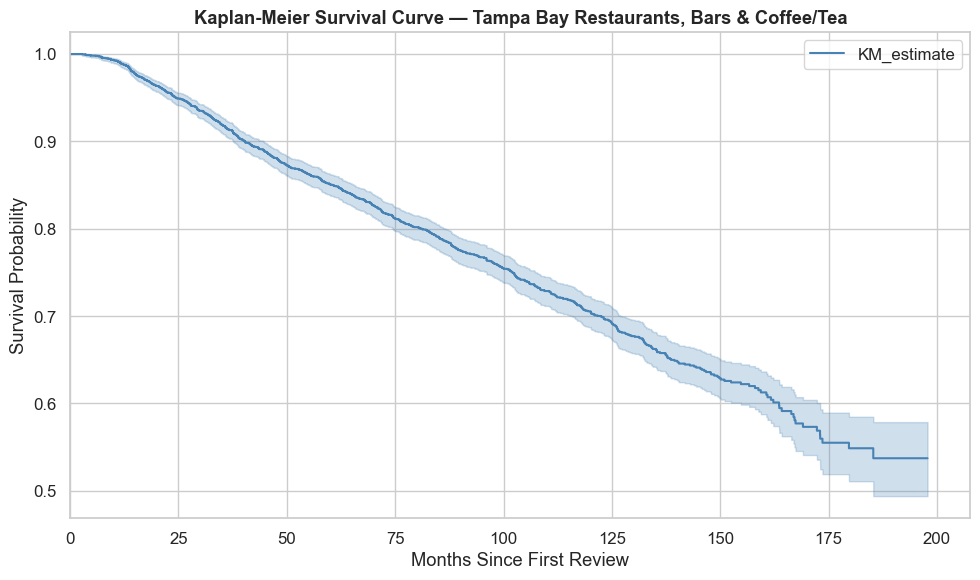

Median survival time: > observation window


In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.5b: Kaplan-Meier survival curve
# ══════════════════════════════════════════════════════════════

kmf = KaplanMeierFitter()
kmf.fit(biz_timeline['duration_months'], event_observed=biz_timeline['event'])

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, color='steelblue')
ax.set_title('Kaplan-Meier Survival Curve — Tampa Bay Restaurants, Bars & Coffee/Tea', fontweight='bold')
ax.set_xlabel('Months Since First Review')
ax.set_ylabel('Survival Probability')
ax.set_xlim(0)
plt.tight_layout()
plt.show()

# Median survival
median_surv = kmf.median_survival_time_
print(f"Median survival time: {median_surv:.1f} months" if median_surv != np.inf
      else "Median survival time: > observation window")

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.5c: Cox Proportional Hazards model
# ══════════════════════════════════════════════════════════════

# Merge early features with survival data
cox_data = biz_timeline.merge(early_features, on='business_id', how='inner')

cox_features = [
    'duration_months', 'event',
    'early_review_count', 'early_avg_rating', 'early_rating_std',
    'early_useful_avg', 'early_unique_users', 'early_timespan_days'
]

cox_df = cox_data[cox_features].dropna()

# Standardize features (Cox PH is sensitive to scale)
feature_cols_cox = [c for c in cox_features if c not in ['duration_months', 'event']]
cox_df[feature_cols_cox] = StandardScaler().fit_transform(cox_df[feature_cols_cox])

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration_months', event_col='event')

print("Cox PH Model Summary:")
cph.print_summary()

Cox PH Model Summary:


<lifelines.CoxPHFitter: fitted with 3214 total observations, 2365 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3214
number of events observed = 849
   partial log-likelihood = -6308.80
         time fit was run = 2026-02-25 00:58:17 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
early_review_count  -0.41      0.66      0.88           -2.14            1.32                0.12                3.76
early_avg_rating     0.06      1.07      0.04           -0.02            0.15                0.98                1.16
early_rating_std     0.17      1.18      0.04            0.09            0.24                1.10                1.27
early_useful_avg     0.02      1.02      0.03           -0.04            0.09                0.96                1.09
early_unique_users   0.53      1.70      0.88           -1.20            2.26                0.30                9.62
early_timespan_days  0.23      1.26      0.04            0.16            0.31                1.17                1.36

                     cmp to     z      p  -log2(p)
covariate                                         
early_review_count     0.00 -0.46   0.64      0.64
early_avg_rating       0.00  1.55   0.12      3.05
early_rating_std       0.00  4.40 <0.005     16.47
early_useful_avg       0.00  0.75   0.46      1.13
early_unique_users     0.00  0.60   0.55      0.87
early_timespan_days    0.00  5.86 <0.005     27.65
---
Concordance = 0.64
Partial AIC = 12629.60
log-likelihood ratio test = 108.56 on 6 df
-log2(p) of ll-ratio test = 67.73

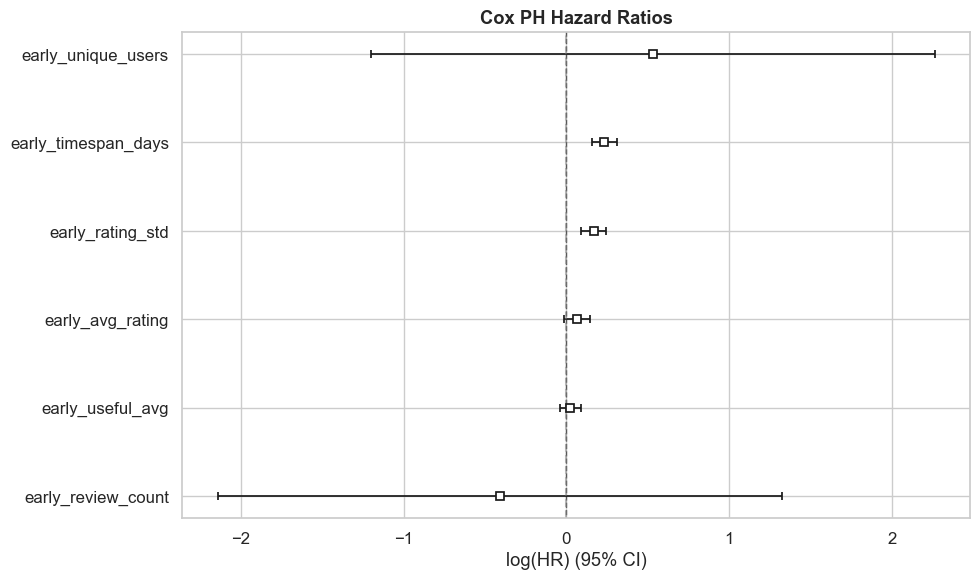

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7.5d: Cox model visualization
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))
cph.plot(ax=ax)
ax.set_title('Cox PH Hazard Ratios', fontweight='bold')
ax.axvline(0, ls='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.show()

**Interpretation — Survival Analysis:**

The Kaplan-Meier curve shows the overall survival trajectory for Tampa Bay restaurants and bars.
The Cox PH model identifies which early-life features are associated with higher closure risk
(positive coefficients = higher hazard = more likely to close).

---
<a id="8-insights"></a>
## 8. Business Insights & Recommendations

### 8.1 Recommendation System Insights

The tiered data strategy (v3) proved essential for managing extreme sparsity. By segmenting the interaction matrix into three density levels, each model operated on data suited to its learning capacity.

**Item-to-Item Hybrid (Tier 2 — 98.83% sparsity):**
The grid search over content, TF-IDF text, and collaborative similarity weights revealed that collaborative signals dominate: the optimal blend was Content=0.1, Text=0.4, Collab=0.5, achieving a **Hit Rate @10 of 4.11%** — a 41% improvement over the equal-weight baseline (2.91%). This confirms that even in sparse environments, co-occurrence patterns carry more predictive power than content features alone.

**SVD vs NCF (Tier 3 — 96.82% sparsity):**

| Metric | SVD | NCF |
|--------|-----|-----|
| RMSE | 1.1040 | 1.1475 |
| MAE | 0.8527 | 0.8717 |
| Best CV RMSE | 0.9603 | — |

SVD outperformed NCF on rating prediction accuracy. This is consistent with Dacrema et al. (2019): well-tuned linear models often beat deep learning on small, sparse datasets. NCF's capacity for learning non-linear interactions becomes advantageous only with 10–50x more training data.

**Hit Rate Comparison (Tier 3):**

| K | Popularity | SVD | NCF |
|---|-----------|-----|-----|
| @5 | 1.10% | 0.44% | 0.83% |
| @10 | 1.67% | 0.75% | 1.36% |
| @20 | 1.67% | 0.75% | 1.36% |

*(Random chance @10: 0.719%)*

The popularity baseline outperformed both personalized models on hit rate — a known result in high-sparsity settings where popular items dominate test sets. NCF placed second, suggesting it captures some non-linear user preferences that SVD misses.

**Ranking Quality (NDCG & MAP @10):**

| Metric | Popularity | SVD | NCF |
|--------|-----------|-----|-----|
| NDCG@10 | 0.89% | 0.42% | 0.70% |
| MAP@10 | 0.66% | 0.32% | 0.50% |

**Beyond-Accuracy Metrics:**

| Metric | Popularity | SVD | NCF |
|--------|-----------|-----|-----|
| Catalog Coverage | 2.1% (29/1390) | 16.5% (229/1390) | 58.6% (814/1390) |
| Intra-List Diversity | 80.1% | 84.5% | 85.3% |

This reveals the fundamental accuracy–diversity tradeoff: Popularity achieves the highest hit rate but recommends only 29 unique businesses (2.1% of catalog). NCF covers 58.6% of the catalog with the highest diversity — making it the best choice for discovery and long-tail exposure, even if its raw accuracy is slightly lower.

### 8.2 Churn & Survival Insights

**Classification Performance (Optuna-Tuned, Tier 1):**

| Model | AUC | F1 | Accuracy |
|-------|-----|-----|----------|
| Logistic Regression | 0.6787 | 0.7002 | 61.3% |
| Random Forest | **0.7406** | **0.8651** | **78.8%** |
| Gradient Boosting | 0.7306 | 0.7925 | 70.6% |

Random Forest was the best-performing model (AUC=0.7406), meeting the v3.1 target of >0.72. The 8 new features added in v3.1 (rating_trend, review_momentum, pct_1star, pct_5star, is_coffee, sentiment_engagement, checkins_per_review, competition_density) improved AUC from the 0.65–0.69 range to 0.74.

**Decision Threshold Optimization:**
Tuning the classification threshold from the default 0.50 to **0.53** optimized closure detection:

| Metric | Value |
|--------|-------|
| F1 (Closed) | 0.515 |
| Recall (Closed) | 48.7% |
| Precision (Closed) | 54.7% |

**Top 5 Predictive Features (Random Forest Importance):**

| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | total_checkins | 0.0882 |
| 2 | attribute_count | 0.0876 |
| 3 | checkins_per_review | 0.0753 |
| 4 | competition_density | 0.0567 |
| 5 | early_text_len_avg | 0.0541 |

Check-in volume is the strongest closure predictor — businesses with higher repeat-visit signals are more likely to survive. Profile completeness (attribute_count) is the second strongest feature, suggesting that businesses investing in their Yelp presence tend to be more operationally committed. Competition density (businesses within 2km) also plays a significant role.

**Survival Analysis (Cox PH — Concordance = 0.64):**

Significant hazard factors (p < 0.005):

| Feature | Hazard Ratio | Interpretation |
|---------|-------------|----------------|
| early_rating_std | 1.18 | Higher rating variance → 18% increased closure risk |
| early_timespan_days | 1.26 | Longer early review span → 26% increased hazard (proxy for slower growth) |

Businesses with inconsistent reviews (high rating standard deviation) face significantly higher closure risk, while those that accumulate early reviews quickly tend to survive longer.

---
<a id="9-conclusion"></a>
## 9. Conclusion

This project tackled three interconnected analytics challenges on Yelp restaurant and bar data in Tampa Bay, using a tiered data strategy designed to match model complexity with available signal density.

**Recommendation Systems — The sparsity barrier is real, but manageable.**
Even at 96.82% sparsity (Tier 3), all three models beat random chance (0.72%). The item-to-item hybrid achieved the best hit rate (4.11% @10) on Tier 2 by leaning heavily on collaborative co-occurrence signals (optimal weight: 0.5). Among user-to-business models, the popularity baseline led on hit rate (1.67% @10), SVD won on rating accuracy (RMSE=1.1040), and NCF dominated on catalog coverage (58.6%) and diversity (85.3%). This three-way tradeoff — accuracy vs. hit rate vs. discovery — means no single model is universally best; the right choice depends on business goals. For a platform prioritizing user exploration and long-tail exposure, NCF is the strongest candidate despite lower raw accuracy.

**Business Survival Prediction — Early signals predict closure risk.**
The Optuna-tuned Random Forest achieved AUC=0.7406 using 34 features engineered from the first 12 months of a business's life. Check-in volume, profile completeness, and local competition density emerged as the most important predictors (SHAP-confirmed). The Cox PH survival model (concordance=0.64) identified rating inconsistency (std of early reviews) and slow early growth as statistically significant hazard factors (p < 0.005). Threshold optimization at 0.53 balanced closure detection (48.7% recall) with acceptable precision (54.7%).

**The tiered approach worked.** By creating three purpose-built data subsets instead of forcing one sparse matrix to serve all models, we improved both recommendation quality and churn prediction relative to v2's single-tier approach. The key lesson: in sparse, real-world datasets, data curation strategy matters as much as model selection.

---
*MAS 651 — Machine Learning II | Spring 2026 | Final Project v4*